# 03 - Exploratory Data Analysis (EDA)
---
## Contexto

Este notebook dá continuidade ao pipeline analítico iniciado nas etapas de **Data Audit** e **Data Cleaning**.

A base utilizada é `vendas_tratadas.csv` — resultado do processo de preparação documentado no notebook anterior — contendo apenas registros com **Quantidade Vendida > 0** e com o campo `Valor_Total_Corrigido` calculado pela regra de negócio validada:

$$
Valor\ Total\ Corrigido = Preço\ Unitário \times Quantidade\ Vendida \times (1 - Desconto)
$$

---

## Objetivos da EDA

Conduzir análise exploratória orientada a KPIs de negócio, respondendo às seguintes **perguntas estratégicas**:

1. Qual é a receita total e como ela evoluiu ao longo do período?
2. Existe crescimento consistente entre os anos?
3. Quais categorias impulsionam a receita?
4. Quais produtos têm maior representatividade?
5. O ticket médio varia por meio de pagamento?
6. Existem padrões sazonais relevantes?
7. Como a distribuição geográfica impacta as vendas?

---

## Estrutura do Notebook

| Seção | Conteúdo |
|-------|----------|
| 01 | Imports e Configurações |
| 02 | Carregamento e Inspeção da Base Tratada |
| 03 | Feature Engineering Temporal |
| 04 | Análise de Receita e Volume |
| 05 | Análise Temporal e Sazonalidade |
| 06 | Análise por Categoria |
| 07 | Análise por Produto |
| 08 | Análise por Forma de Pagamento |
| 09 | Análise Geográfica |
| 10 | Correlações e Distribuições |
| 11 | Conclusões e Próximos Passos |

---
# 01 - Imports e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from statsmodels.tsa.seasonal import seasonal_decompose
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# Formatação monetária
def fmt_brl(valor):
    return f'R$ {valor:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.')

---
# 02 - Carregamento e Inspeção da Base Tratada

In [2]:
df = pd.read_csv('../data/processed/vendas_tratadas.csv', parse_dates=['Data da Venda'])
df.head()

,ID da Venda,Data da Venda,Produto,Categoria,Preço Unitário,Quantidade Vendida,Desconto,Valor Total,Localização,Forma de Pagamento,id_registro,flag_quantidade_invalida,Valor_Total_Corrigido
0,1001,2023-01-01 00:00:00.000000000,Livro G,Livros,60.00,6,0.05,57.00,Curitiba,Pix,1,False,342.0000
1,1002,2023-01-01 05:49:40.386924616,Camisa D,Roupas,80.00,4,0.04,307.20,Salvador,Cartão de Débito,2,False,307.2000
2,1003,2023-01-01 11:39:20.773849232,Calça E,Roupas,120.00,6,0.02,705.60,Curitiba,Boleto,3,False,705.6000
3,1004,2023-01-01 17:29:01.160773849,Livro G,Livros,60.00,2,0.02,117.60,Salvador,Pix,4,False,117.6000
4,1005,2023-01-01 23:18:41.547698465,Fone C,Eletrônicos,1626.54,2,0.07,3025.36,São Paulo,Cartão de Débito,5,False,3025.3644


In [3]:
# format="mixed" necessário devido à inconsistência de precisão temporal
# identificada na auditoria (nanosegundos vs segundos)
df["Data da Venda"] = pd.to_datetime(
    df["Data da Venda"],
    format="mixed"
)

In [4]:
print(f"Dimensão da base analítica: {df.shape[0]} linhas e {df.shape[1]} colunas")
print(f"Período coberto: {df["Data da Venda"].min().date()} até {df["Data da Venda"].max().date()}")
print(f"Colunas disponíveis: {list(df.columns)}")

Dimensão da base analítica: 12830 linhas e 13 colunas
Período coberto: 2023-01-01 até 2026-01-15
Colunas disponíveis: ['ID da Venda', 'Data da Venda', 'Produto', 'Categoria', 'Preço Unitário', 'Quantidade Vendida', 'Desconto', 'Valor Total', 'Localização', 'Forma de Pagamento', 'id_registro', 'flag_quantidade_invalida', 'Valor_Total_Corrigido']


---
**Nota:** A base analítica utilizada aqui é o resultado direto do notebook `02_data_cleaning.ipynb`.
Contém apenas registros com `Quantidade Vendida > 0` (12.830 linhas de 13.094 originais) e o campo `Valor_Total_Corrigido` como métrica financeira oficial.

---
**Filtro Temporal: Exclusão do Ano de 2026**

Durante a auditoria, foram identificados 65 registros com data `2026-01-15 10:00:00`, caracterizados como datas inválidas ou placeholder.

Esses registros sobreviveram à etapa de limpeza pois não foram tratados como problema de qualidade naquele momento, mas comprometem análises temporais por representarem um ano incompleto com apenas 63 transações.

**Decisão:** registros de 2026 serão excluídos da base analítica para garantir integridade das métricas de sazonalidade, crescimento e ticket médio.

In [5]:
df_original = df.copy()
df = df[df["Data da Venda"].dt.year <= 2025]
print(f"Dimensão da base analítica: {df.shape[0]} linhas e {df.shape[1]} colunas")
print(f"Período coberto: {df["Data da Venda"].min().date()} até {df["Data da Venda"].max().date()}")
print(f"Colunas disponíveis: {list(df.columns)}")

Dimensão da base analítica: 12767 linhas e 13 colunas
Período coberto: 2023-01-01 até 2025-12-31
Colunas disponíveis: ['ID da Venda', 'Data da Venda', 'Produto', 'Categoria', 'Preço Unitário', 'Quantidade Vendida', 'Desconto', 'Valor Total', 'Localização', 'Forma de Pagamento', 'id_registro', 'flag_quantidade_invalida', 'Valor_Total_Corrigido']


---
# 03 - Feature Engineering Temporal

Derivação de variáveis temporais a partir de `Data da Venda` para habilitar análises de sazonalidade, tendências e comportamento por período.

In [36]:
df["Ano"] = df["Data da Venda"].dt.year
df["Mes"] = df["Data da Venda"].dt.month
df["Trimestre"] = df["Data da Venda"].dt.quarter
df["Dia_Semana"] = df["Data da Venda"].dt.dayofweek
df["Ano_Mes"] = df["Data da Venda"].dt.to_period("M")

print("Features temporais criadas com sucesso")
df[["Data da Venda", "Ano", "Mes", "Trimestre", "Dia_Semana", "Nome_Mes", "Ano_Mes"]].tail()

Features temporais criadas com sucesso


,Data da Venda,Ano,Mes,Trimestre,Dia_Semana,Nome_Mes,Ano_Mes
12825,2025-12-31 13:35:45,2025,12,4,2,Dez,2025-12
12826,2025-12-31 15:33:00,2025,12,4,2,Dez,2025-12
12827,2025-12-31 16:45:51,2025,12,4,2,Dez,2025-12
12828,2025-12-31 18:46:52,2025,12,4,2,Dez,2025-12
12829,2025-12-31 18:47:21,2025,12,4,2,Dez,2025-12


---
# 04 - Análise de Receita e Volume

Visão geral dos principais indicadores financeiros e operacionais da base.

## 04.1 - KPIs Gerais

In [7]:
receita_total = df["Valor_Total_Corrigido"].sum()
total_transacoes = len(df)
ticket_medio = receita_total / total_transacoes
qtd_total = df["Quantidade Vendida"].sum()
desconto_medio = df["Desconto"].mean()

print("=" * 45)
print("KPIs GERAIS DO PERÍODO (2023-2025)")
print("=" * 45)
print(f"Receita Total: {fmt_brl(receita_total)}")
print(f"Total de Transações: {str(f"{total_transacoes:,}").replace(",", ".")}")
print(f'Unidades Vendidas: {str(f"{qtd_total:,}").replace(",", ".")}')
print(f"Ticket Médio: {fmt_brl(ticket_medio)}")
print(f"Desconto Médio: {desconto_medio:.1%}")
print("=" * 45)

KPIs GERAIS DO PERÍODO (2023-2025)
Receita Total: R$ 45.432.917,72
Total de Transações: 12.767
Unidades Vendidas: 38.760
Ticket Médio: R$ 3.558,62
Desconto Médio: 9.6%


## 04.2 - Receita e Volume por Ano

In [35]:
receita_ano = (
    df.groupby("Ano")
    .agg(
        Receita=("Valor_Total_Corrigido", "sum"),
        Transacoes=("id_registro", "count"),
        Ticket_Medio=("Valor_Total_Corrigido", "mean")
    )
    .reset_index()
)

receita_ano["Crescimento_Receita"] = receita_ano["Receita"].pct_change().map(
    lambda x: f"+{x:.1%}" if pd.notna(x) and x >= 0 else (f"{x:.1%}" if pd.notna(x) else "—")
)

receita_ano["Receita_fmt"] = receita_ano["Receita"].apply(fmt_brl)
receita_ano["Ticket_Medio_fmt"] = receita_ano["Ticket_Medio"].apply(fmt_brl)

print(receita_ano[["Ano", "Receita_fmt", "Transacoes", "Ticket_Medio_fmt", "Crescimento_Receita"]].to_string(index=False))

 Ano      Receita_fmt  Transacoes Ticket_Medio_fmt Crescimento_Receita
2023  R$ 3.813.923,58        1459      R$ 2.614,07                   —
2024 R$ 16.718.852,42        4618      R$ 3.620,37             +338.4%
2025 R$ 24.900.141,72        6690      R$ 3.721,99              +48.9%


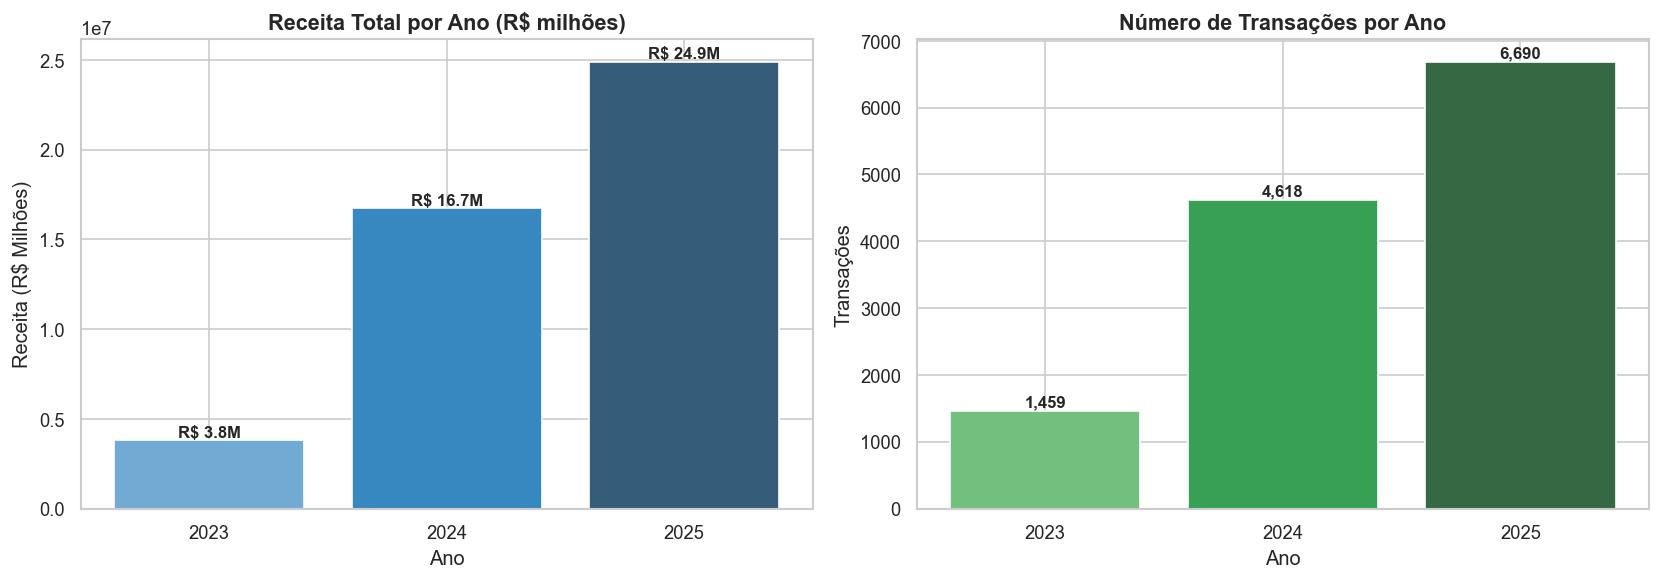

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
#####################################################
# Gráfico 1 - Receita Total por Ano
#####################################################
bars = axes[0].bar(receita_ano["Ano"], 
                   receita_ano["Receita"],
                   color=sns.color_palette("Blues_d", len(receita_ano)))
axes[0].set_title("Receita Total por Ano (R$ milhões)")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Receita (R$ Milhões)")
axes[0].set_xticks(receita_ano["Ano"])
# Rótulo de Dados
for bar, val in zip(bars, receita_ano["Receita"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, 
                 bar.get_height() + 0.1,
                 f'R$ {val/1e6:.1f}M',
                 ha="center",
                 va="bottom",
                 fontsize=10,
                 fontweight="bold")


####################################################
# Gráfico 2 - Número de Transações por Ano
####################################################
bars2 = axes[1].bar(receita_ano["Ano"],
                    receita_ano["Transacoes"],
                    color=sns.color_palette("Greens_d", len(receita_ano)))
axes[1].set_title("Número de Transações por Ano")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Transações")
axes[1].set_xticks(receita_ano["Ano"])
# Rótulo de Dados
for bar, val in zip(bars2, receita_ano["Transacoes"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 20,
                 f'{val:,}',
                 ha="center",
                 va="bottom",
                 fontsize=10,
                 fontweight="bold")

plt.tight_layout()
plt.show()


---
**Análise — Receita e Transações por Ano**

A operação apresentou crescimento consistente ao longo de todo o período analisado:

- A receita saltou de **R\$ 3,8 milhões** em 2023 para **R\$ 24,9 milhões** em 2025, um crescimento acumulado de aproximadamente **553%** em dois anos.
- O crescimento mais expressivo ocorreu entre 2023 e 2024 (**+338,4%**), sugerindo uma expansão acelerada da operação nesse intervalo — seja por aumento de base de clientes, novos produtos ou maior volume de pedidos.
- Entre 2024 e 2025 o crescimento continuou forte (**+48,9%**), porém em ritmo mais moderado, o que pode indicar uma fase de maturação após a expansão inicial.
- O número de transações acompanhou a receita: de **1.459** em 2023 para **6.690** em 2025, crescimento de **+358%**.
- O ticket médio também cresceu, de **R\$ 2.614** para **R\$ 3.722**, indicando que o crescimento não foi apenas volumétrico — os clientes passaram a realizar compras de maior valor médio ao longo do período.

## 04.3 - Receita Mensal Acumulada (Série Temporal)

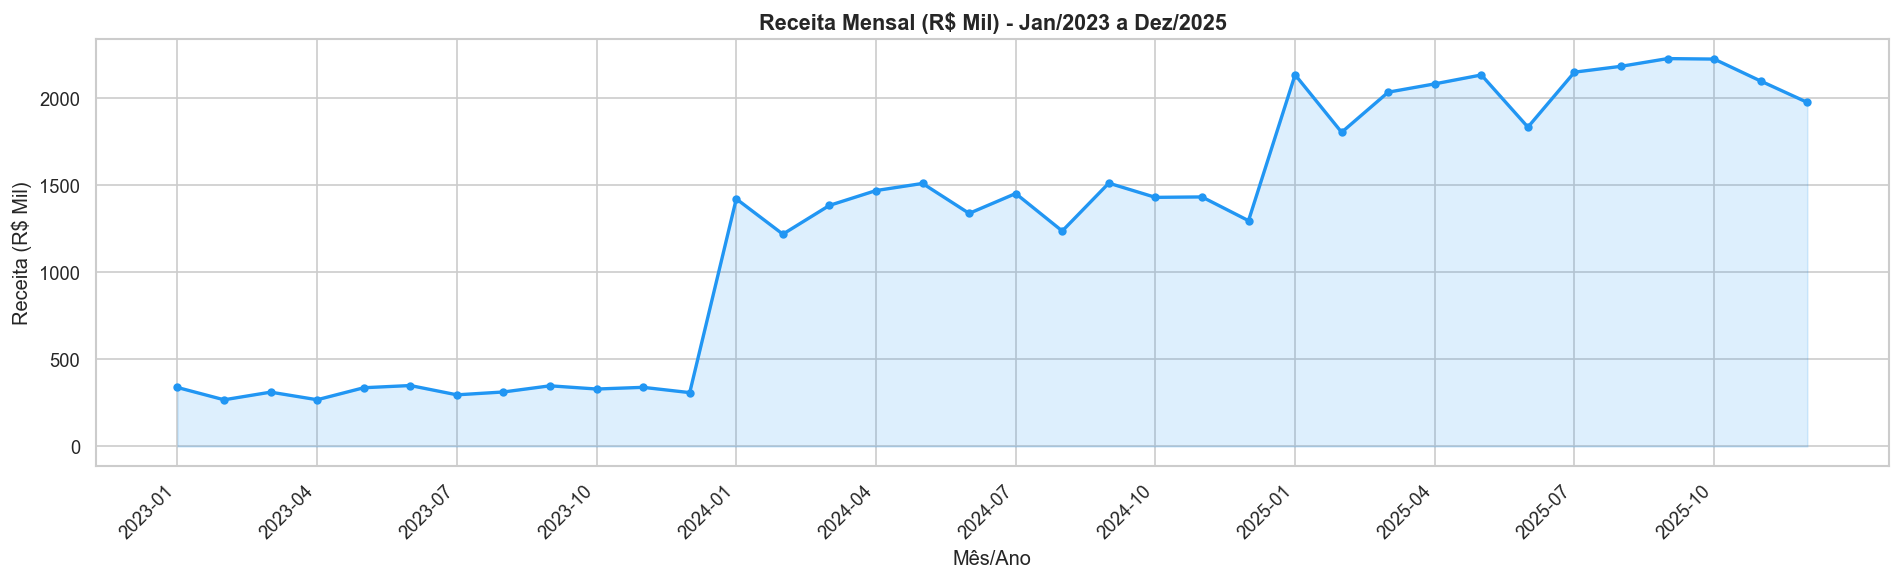

In [10]:
receita_mensal = (
    df.groupby("Ano_Mes")["Valor_Total_Corrigido"]
    .sum()
    .reset_index()
)
receita_mensal["Ano_Mes_str"] = receita_mensal["Ano_Mes"].astype(str)

####################################
# Gráfico
####################################

fig, ax = plt.subplots(figsize=(16,5))
ax.plot(receita_mensal["Ano_Mes_str"], 
        receita_mensal["Valor_Total_Corrigido"] / 1e3,
        marker='o',
        markersize=4,
        linewidth=2,
        color='#2196F3')
ax.fill_between(range(len(receita_mensal)),
                receita_mensal["Valor_Total_Corrigido"] /1e3,
                alpha=0.15,
                color='#2196F3')
ax.set_title('Receita Mensal (R$ Mil) - Jan/2023 a Dez/2025')
ax.set_xlabel('Mês/Ano')
ax.set_ylabel('Receita (R$ Mil)')
step = max(1, len(receita_mensal) // 12)
ax.set_xticks(range(0, len(receita_mensal), step))
ax.set_xticklabels(receita_mensal['Ano_Mes_str'].iloc[::step], rotation=45, ha='right')

plt.tight_layout()
plt.show()

---
**Análise — Receita Mensal (Jan/2023 a Dez/2025)**

A série temporal revela três fases distintas de comportamento:

- **2023 (patamar baixo e estável):** a receita mensal oscilou entre R\$ 270 mil e R\$ 370 mil,
sem crescimento expressivo ao longo do ano, sugerindo uma operação ainda em estágio inicial.

- **Virada em Jan/2024 (ruptura de patamar):** houve um salto abrupto da receita,
que passou de ~R\$ 300 mil para ~R\$ 1,4 milhão em um único mês — um crescimento de
aproximadamente **4,5x**. Esse comportamento não é gradual, o que levanta a hipótese de
um evento pontual: expansão da operação, entrada em novos mercados ou incorporação de
novos dados à base.

- **2024 a 2025 (novo patamar com crescimento moderado):** após a ruptura, a receita se
estabilizou entre R\$ 1,2 milhão e R\$ 2,2 milhões, com tendência de crescimento gradual
ao longo de 2025, encerrando o ano em torno de R\$ 2,0 milhões mensais.

A oscilação dentro de cada ano sugere a presença de sazonalidade, que será investigada
na próxima seção com a decomposição da série temporal.
> ⚠️ **Ressalva analítica:** o salto abrupto observado em Jan/2024 pode distorcer os
> componentes de tendência e sazonalidade na decomposição a seguir. Em um ambiente
> corporativo real, esse comportamento seria investigado junto às áreas de negócio antes
> de avançar para conclusões — possíveis causas incluem expansão da operação, entrada em
> novos mercados ou até mesmo uma mudança na forma de coleta dos dados. Como a base não
> possui variáveis que permitam confirmar a causa, esse ponto é tratado aqui como uma
> limitação da análise.

# 05 - Análise Temporal e Sazonalidade

  ## 05.1 - Decomposição da Série Temporal

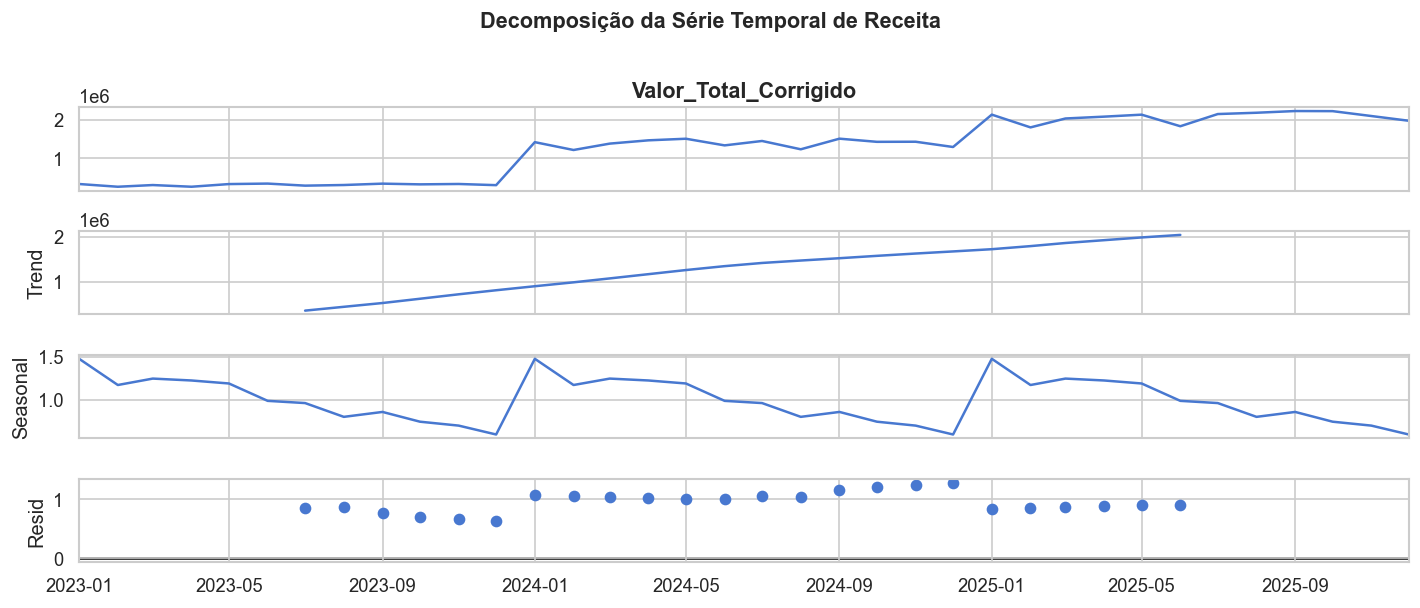

In [11]:
# Preparar série temporal indexada por mês
serie = (
    df.groupby("Ano_Mes")["Valor_Total_Corrigido"]
    .sum()
    .reset_index()
)

serie.index = pd.PeriodIndex(serie["Ano_Mes"], freq="M").to_timestamp()
serie = serie["Valor_Total_Corrigido"]

# Decomposição
decomposicao = seasonal_decompose(serie, model="multiplicative", period=12)
decomposicao.plot()
plt.suptitle("Decomposição da Série Temporal de Receita", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
**Análise — Decomposição da Série Temporal (Modelo Multiplicativo)**

A decomposição separou a série em três componentes interpretáveis:

- **Tendência (Trend):** confirma numericamente o que o gráfico anterior sugeria visualmente —
há uma tendência de crescimento contínua ao longo de todo o período, saindo de aproximadamente
300 mil reais para 2 milhões de reais mensais. O crescimento é praticamente linear após a
ruptura de Jan/2024, o que indica uma expansão sustentada da operação.

- **Sazonalidade (Seasonal):** o componente sazonal apresenta um padrão que se repete a cada
ano, com picos no início do ano (janeiro) e queda progressiva até o segundo semestre,
especialmente entre agosto e outubro. Esse comportamento sugere que o e-commerce tem
desempenho relativamente mais forte no primeiro trimestre e mais fraco no terceiro trimestre.

- **Resíduo (Resid):** os resíduos oscilam próximos a 1,0, o que é esperado em um modelo
multiplicativo e indica que tendência e sazonalidade explicam bem o comportamento da série,
sem ruídos expressivos. A exceção são os extremos da série (início e fim), que apresentam
valores nulos — comportamento esperado dado que a base possui apenas 36 meses, o mínimo
necessário para o `period=12`.

> ⚠️ **Limitação:** com apenas 3 ciclos anuais disponíveis, o padrão sazonal identificado
> deve ser interpretado com cautela. Uma sazonalidade robusta idealmente exigiria 5 ou mais
> anos de dados para ser confirmada com maior confiança estatística.

## 05.2 - Receita Média por Mês

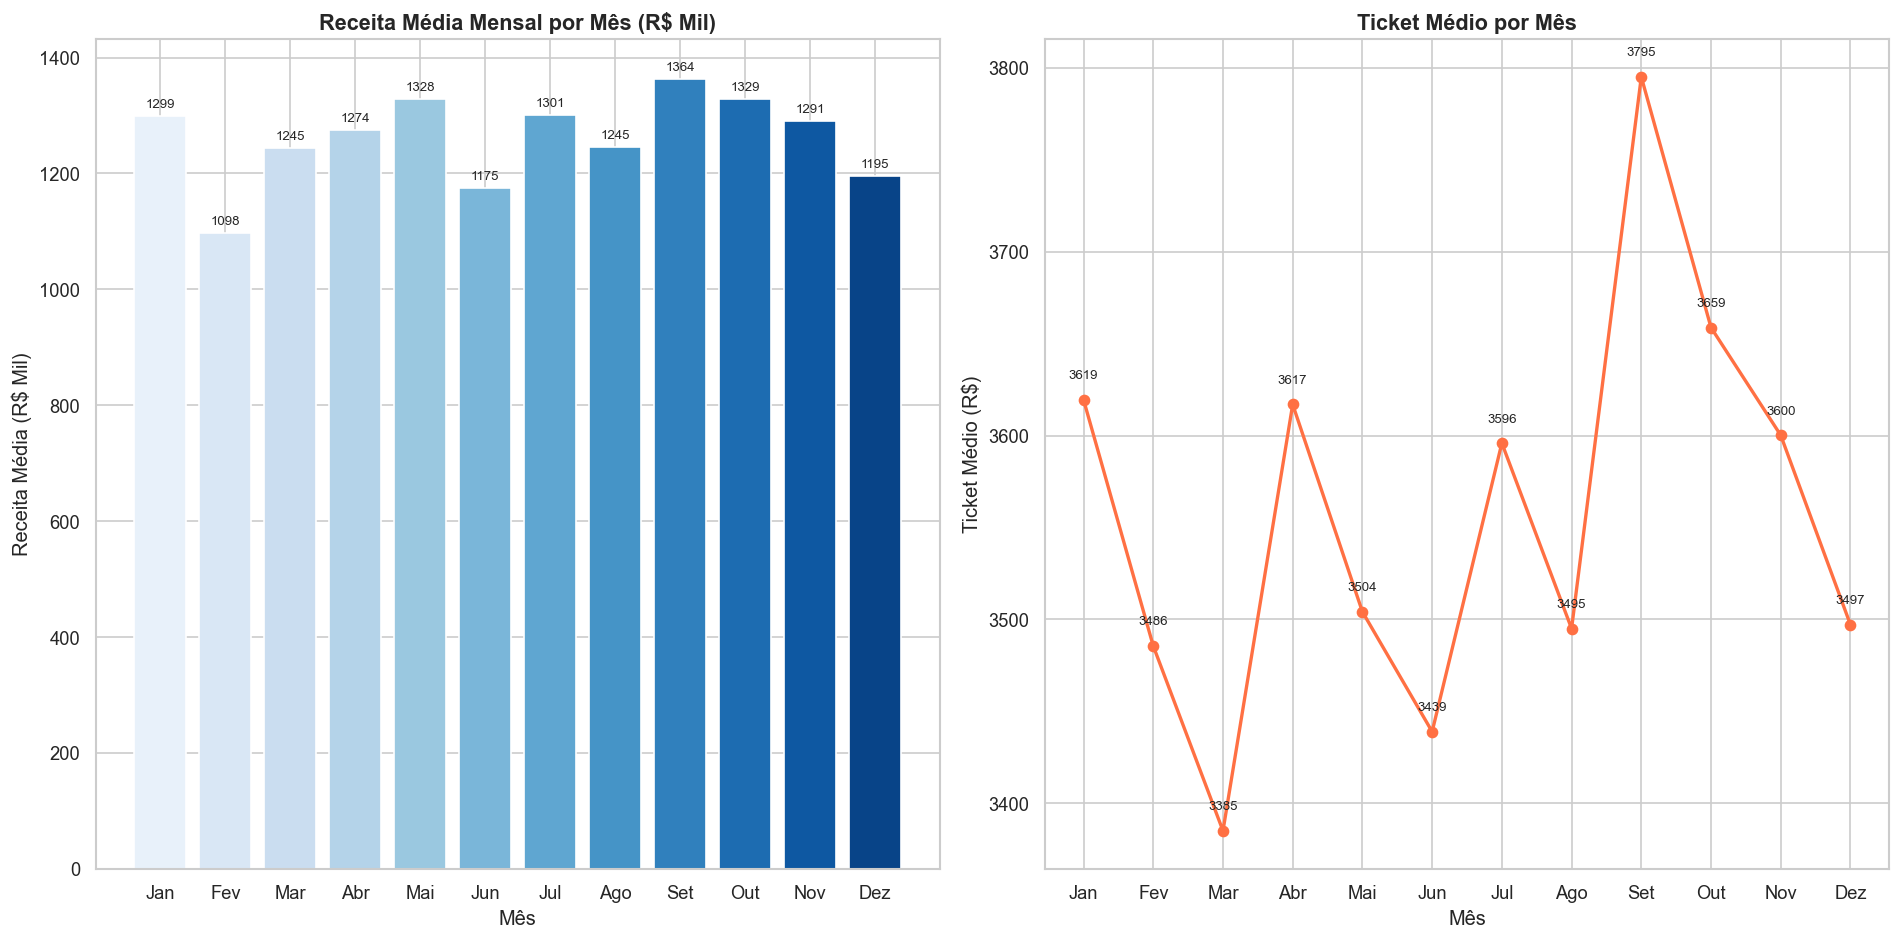

In [12]:
mapa_mes = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
            7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}

df['Nome_Mes'] = df['Mes'].map(mapa_mes)

nomes_mes = (
    df.groupby('Mes')['Nome_Mes']
    .first()
    .tolist()
)


sazon_mes = (
    df.groupby('Mes')['Valor_Total_Corrigido']
    .mean()
    .reset_index()
    .rename(columns={'Valor_Total_Corrigido':'Ticket_Medio_Mes'})
)

sazon_receita = (
    df.groupby(['Ano', 'Mes'])['Valor_Total_Corrigido']
    .sum()
    .groupby('Mes')
    .mean()
    .reset_index()
    .rename(columns={'Valor_Total_Corrigido':'Receita_Media_Mes'})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

############################################################
# Gráfico 1 - Receita Média Mensal
############################################################
bars = axes[0].bar(range(1, 13), sazon_receita['Receita_Media_Mes'] / 1e3,
                   color=sns.color_palette('Blues', 12))
axes[0].set_title('Receita Média Mensal por Mês (R$ Mil)')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Receita Média (R$ Mil)')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(nomes_mes)
# Rótulo de Dados
for bar, val in zip(bars, sazon_receita['Receita_Media_Mes']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 10,
                 f'{val/1e3:.0f}',
                 ha='center', va='bottom', fontsize=8)

############################################################
# Gráfico 2 - Ticket Médio por Mês
############################################################
axes[1].plot(range(1, 13), sazon_mes['Ticket_Medio_Mes'],
             marker='o', linewidth=2, color='#FF7043')
axes[1].set_title('Ticket Médio por Mês')
axes[1].set_xlabel('Mês')
axes[1].set_ylabel('Ticket Médio (R$)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(nomes_mes)
# Rótulo de Dados
for x, val in zip(range(1, 13), sazon_mes['Ticket_Medio_Mes']):
    axes[1].text(x, val + 10, f'{val:.0f}',
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

---
**Análise — Receita Média e Ticket Médio por Mês**

- **Receita Média Mensal:** a variação entre os meses é relativamente pequena,
oscilando entre aproximadamente 1.100 mil reais (Fev) e 1.370 mil reais (Set).
Fevereiro se destaca como o mês mais fraco e Setembro como o mais forte.
Não há um padrão sazonal claro e pronunciado — a receita se mantém em um
patamar relativamente estável ao longo do ano, com variação de apenas ~25%
entre o mês mais fraco e o mais forte.

- **Ticket Médio por Mês:** apresenta comportamento mais volátil, com oscilações
mais pronunciadas. Os meses de Março e Junho registram os menores tickets
(em torno de 3.390 e 3.450 reais respectivamente), enquanto Setembro apresenta
o pico mais expressivo (~3.800 reais). Essa volatilidade no ticket médio,
sem um padrão regular, sugere que o valor médio de compra é influenciado
por fatores pontuais — como mix de produtos vendidos em cada mês — mais do
que por um comportamento sazonal estruturado.

De forma geral, os gráficos reforçam a conclusão da decomposição: a sazonalidade
existe mas é suave, sem meses claramente dominantes ou deprimidos no período analisado.

  ## 05.3 - Receita por Trimestre

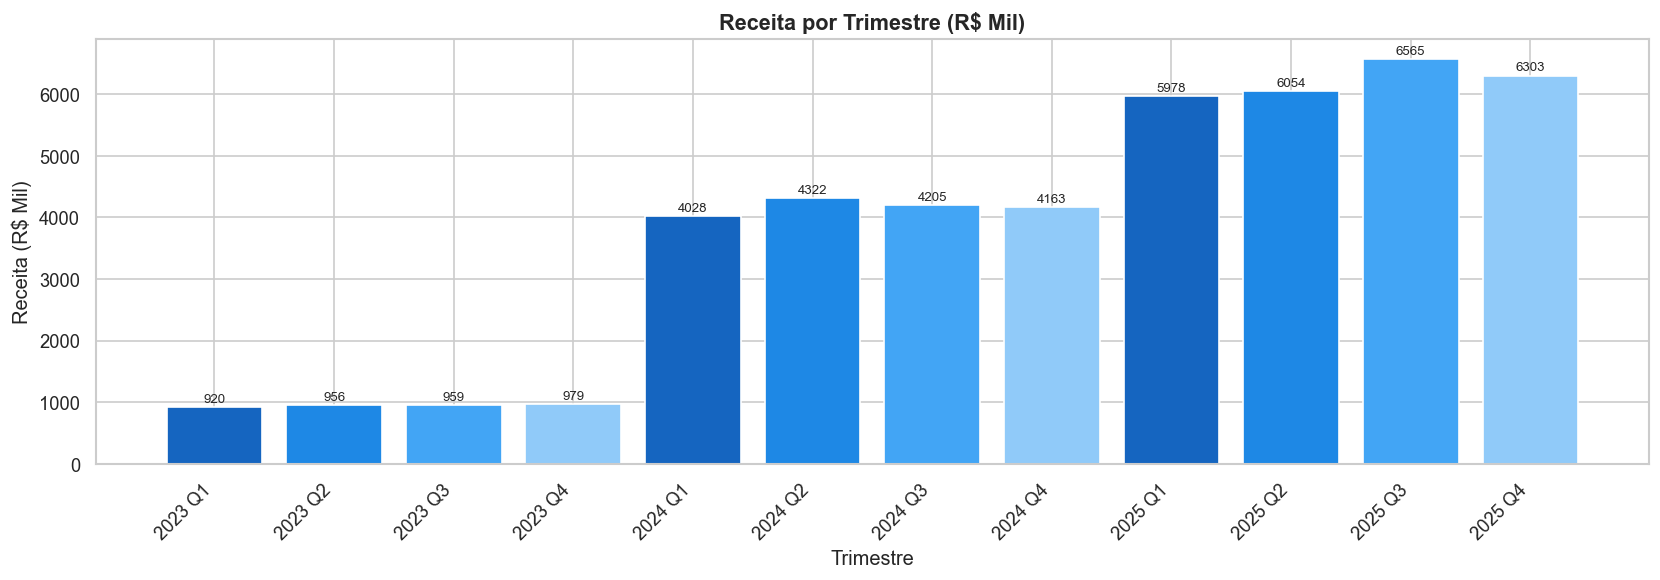

In [13]:
trim = (
    df.groupby(['Ano', 'Trimestre'])['Valor_Total_Corrigido']
    .sum()
    .reset_index()
)
trim['Periodo'] = trim['Ano'].astype(str) + ' Q' + trim['Trimestre'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))

############################################################
# Gráfico  - Receita por Trimestre
############################################################
colors_trim = ['#1565C0', '#1E88E5', '#42A5F5', '#90CAF9']
palette_trim = [colors_trim[(q - 1) % 4] for q in trim['Trimestre']]
bars = ax.bar(trim['Periodo'], trim['Valor_Total_Corrigido'] / 1e3, color=palette_trim)
ax.set_title('Receita por Trimestre (R$ Mil)')
ax.set_xlabel('Trimestre')
ax.set_ylabel('Receita (R$ Mil)')
ax.set_xticklabels(trim['Periodo'], rotation=45, ha='right')


# Rótulo de Dados
for bar, val in zip(bars, trim['Valor_Total_Corrigido']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30,
            f'{val/1e3:.0f}',
            ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

---
**Análise — Receita por Trimestre**

A visão trimestral reforça o crescimento consistente da operação e permite identificar o comportamento intra-anual com mais clareza:

- **2023:** os quatro trimestres foram praticamente estáveis, variando entre 920 mil reais (Q1) e 979 mil reais (Q4), sem sazonalidade trimestral relevante.

- **2024:** houve um salto expressivo já no Q1 (4.028 mil reais), confirmando a ruptura de patamar identificada na série mensal. O Q2 foi o mais forte (4.322 mil reais), seguido de uma leve queda no Q3 (4.205 mil reais) e Q4 (4.163 mil reais), sugerindo um padrão de aquecimento no primeiro semestre e leve arrefecimento no segundo.

- **2025:** o crescimento continuou com todos os trimestres superando os de 2024. O Q3 foi o mais forte do ano e de todo o período analisado (6.565 mil reais), seguido do Q4 (6.303 mil reais), Q2 (6.054 mil reais) e Q1 (5.978 mil reais) — o que inverte o padrão de 2024, com o segundo semestre sendo mais forte que o primeiro.

A ausência de um padrão trimestral consistente entre os anos reforça a conclusão da decomposição: a sazonalidade é suave e ainda não consolidada, possivelmente porque a operação está em fase de crescimento acelerado, o que tende a mascarar efeitos sazonais estruturais.

 ## 05.4 - Heatmap Mês × Ano

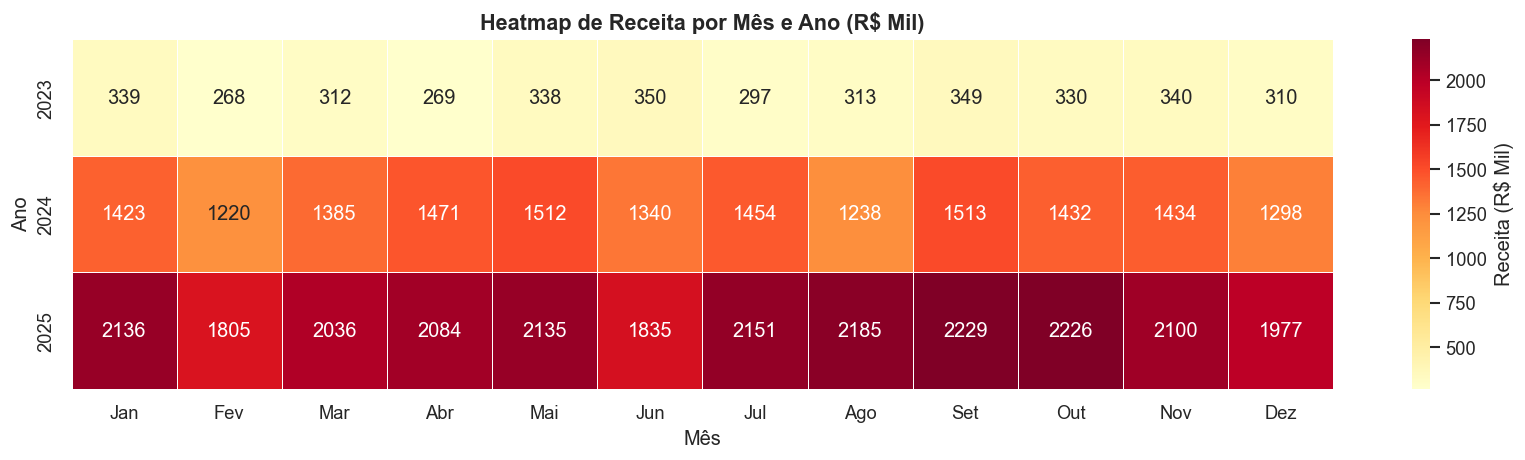

In [14]:
heat_data = (
    df.groupby(['Ano', 'Mes'])['Valor_Total_Corrigido']
    .sum()
    .reset_index()
    .pivot(index='Ano', columns='Mes', values='Valor_Total_Corrigido')
)
heat_data.columns = nomes_mes[:len(heat_data.columns)]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    heat_data / 1e3,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Receita (R$ Mil)'}
)
ax.set_title('Heatmap de Receita por Mês e Ano (R$ Mil)')
ax.set_xlabel('Mês')
ax.set_ylabel('Ano')
plt.tight_layout()
plt.show()

---
**Análise — Heatmap de Receita por Mês e Ano**

O heatmap permite comparar o desempenho de cada mês entre os três anos, revelando padrões que os gráficos anteriores não deixavam tão evidentes:

- **Crescimento ano a ano é consistente em todos os meses:** qualquer mês de 2025 supera o mesmo mês de 2024, que por sua vez supera 2023. Isso confirma que o crescimento da operação é estrutural e não pontual.

- **Fevereiro é o mês mais fraco nos três anos:** registrou 268 mil reais em 2023, 1.220 mil em 2024 e 1.805 mil em 2025 — sempre o menor valor do respectivo ano, sugerindo que esse é um padrão consistente e não aleatório.

- **O segundo semestre tende a ser mais forte em 2025:** os meses de Jul (2.151), Ago (2.185), Set (2.229) e Out (2.226) concentram os maiores valores do ano, enquanto em 2024 o padrão era inverso, com Jan (1.423) e Mai (1.512) no topo.

- **Dezembro é consistentemente o segundo mês mais fraco:** aparece como o menor ou segundo menor valor em 2023 (310), 2024 (1.298) e 2025 (1.977), o que pode indicar antecipação de compras em novembro ou redução de demanda no final do ano.

O heatmap reforça que **Fevereiro e Dezembro merecem atenção estratégica** como meses de menor performance recorrente, enquanto o segundo semestre de 2025 sinaliza um possível fortalecimento da sazonalidade no período mais recente.

## 05.5 - Distribuição por Dia da Semana

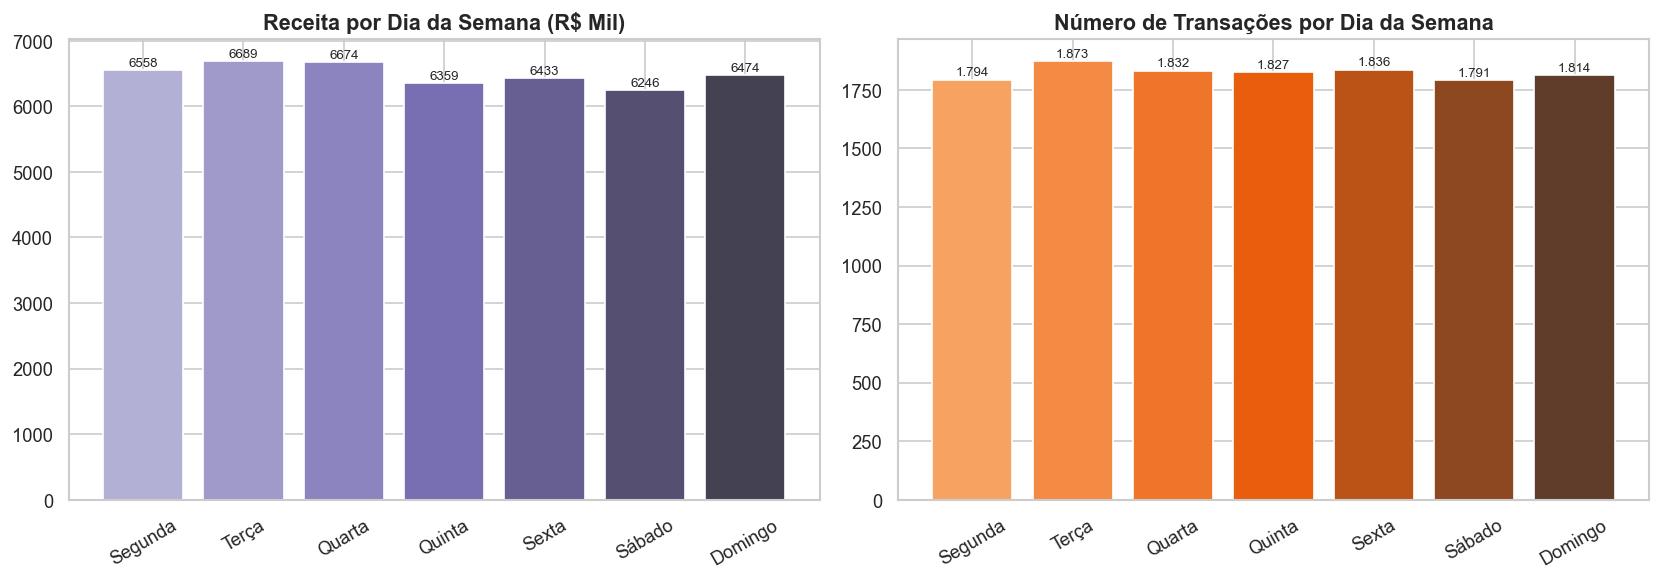

In [15]:
dias_semana_nome = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

dia_sem = (
    df.groupby('Dia_Semana')
    .agg(
        Receita=('Valor_Total_Corrigido', 'sum'),
        Transacoes=('id_registro', 'count')
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
##########################################
# Gráfico 1 - Barras Verticais - Receita
#########################################
bars0 = axes[0].bar(dias_semana_nome, dia_sem['Receita'] / 1e3,
                    color=sns.color_palette('Purples_d', 7))
axes[0].set_title('Receita por Dia da Semana (R$ Mil)')
axes[0].set_xticklabels(dias_semana_nome, rotation=30)

# Rótulo de Dados
for bar, val in zip(bars0, dia_sem['Receita']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 10,
                 f'{val/1e3:.0f}',
                 ha='center', va='bottom', fontsize=8)

    
############################################
# Gráfico 2 - Barras Verticais - Transações
###########################################
bars1 = axes[1].bar(dias_semana_nome, dia_sem['Transacoes'],
                    color=sns.color_palette('Oranges_d', 7))
axes[1].set_title('Número de Transações por Dia da Semana')
axes[1].set_xticklabels(dias_semana_nome, rotation=30)
# Rótulo de Dados
for bar, val in zip(bars1, dia_sem['Transacoes']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 5,
                 f'{val:,}'.replace(',', '.'),
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

---
**Análise — Receita e Transações por Dia da Semana**

A distribuição por dia da semana revela um comportamento bastante uniforme, sem concentração expressiva em nenhum dia específico:

- **Receita:** a variação entre os dias é pequena, oscilando entre 6.246 mil reais (Sábado) e 6.689 mil reais (Terça). A diferença entre o dia mais fraco
e o mais forte é de apenas ~7%, o que indica que o volume de vendas é distribuído de forma homogênea ao longo da semana.

- **Transações:** o padrão se repete, com volume entre 1.791 (Sábado) e 1.873 (Terça) transações. Terça-feira lidera em ambos os indicadores, enquanto Sábado é consistentemente o dia mais fraco nos dois gráficos.

- **Final de semana vs dias úteis:** ao contrário do que seria esperado em alguns modelos de e-commerce, Sábado e Domingo não se destacam positivamente — Sábado é o menor valor em ambos os indicadores e Domingo fica na média. Isso pode indicar um perfil de cliente predominantemente corporativo ou com hábito de compra em horário comercial.

De forma geral, a ausência de concentração em dias específicos sugere que não há necessidade de estratégias diferenciadas por dia da semana — o fluxo de vendas é estável e previsível ao longo de toda a semana.

---
# 06 - Análise por Categoria

Avaliação do mix de produtos e participação de cada categoria na receita total.

## 06.1 - Receita e Volume por Categoria

In [16]:
cat_receita = (
    df.groupby('Categoria')
    .agg(
        Receita=('Valor_Total_Corrigido', 'sum'),
        Transacoes=('id_registro', 'count'),
        Ticket_Medio=('Valor_Total_Corrigido', 'mean'),
        Qtd_Vendida=('Quantidade Vendida', 'sum')
    )
    .sort_values('Receita', ascending=False)
    .reset_index()
)

cat_receita['Participacao_%'] = (cat_receita['Receita'] / cat_receita['Receita'].sum() * 100).round(1)
cat_receita['Receita_fmt'] = cat_receita['Receita'].apply(fmt_brl)
cat_receita['Ticket_fmt'] = cat_receita['Ticket_Medio'].apply(fmt_brl)

print(cat_receita[['Categoria', 'Receita_fmt', 'Participacao_%', 'Transacoes', 'Ticket_fmt']].to_string(index=False))

       Categoria      Receita_fmt  Participacao_%  Transacoes  Ticket_fmt
     Eletrônicos R$ 27.180.820,70            59.8        3727 R$ 7.292,95
          Móveis  R$ 7.443.237,23            16.4        1620 R$ 4.594,59
Eletrodomésticos  R$ 5.116.705,37            11.3        1633 R$ 3.133,32
            Moda  R$ 3.097.944,99             6.8        3188   R$ 971,75
        Educação  R$ 1.845.126,14             4.1        1007 R$ 1.832,30
          Roupas    R$ 400.931,49             0.9         587   R$ 683,02
          Livros    R$ 348.151,79             0.8        1005   R$ 346,42


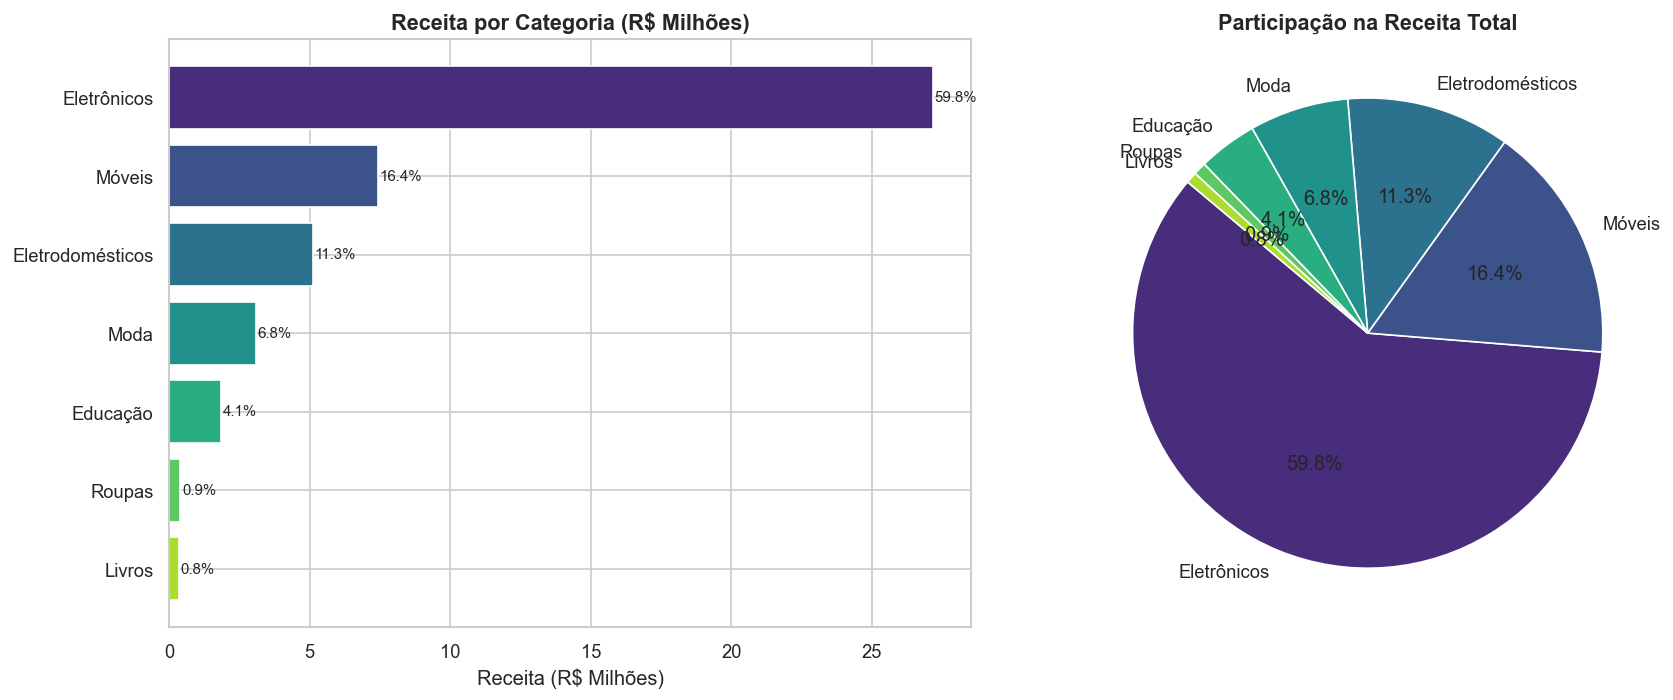

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = sns.color_palette('viridis', len(cat_receita))

############################################
# Gráfico de Barra (Receita por Categoria)
############################################
bars = axes[0].barh(cat_receita['Categoria'], cat_receita['Receita'] / 1e6, color = colors)
axes[0].set_title('Receita por Categoria (R$ Milhões)')
axes[0].set_xlabel('Receita (R$ Milhões)')
axes[0].invert_yaxis()

# Rótulo de Dados
for bar, pct in zip(bars, cat_receita['Participacao_%']):
    axes[0].text(bar.get_width() + 0.05,
                 bar.get_y() + bar.get_height() / 2,
                 f'{pct}%',
                 va='center',
                 fontsize=9)

############################################
# Gráfico de Pizza
############################################
wedges, texts, autotexts = axes[1].pie(
    cat_receita['Receita'],
    labels=cat_receita['Categoria'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)
axes[1].set_title('Participação na Receita Total')

plt.tight_layout()
plt.show()

---
**Análise — Receita por Categoria**

O mix de categorias revela uma concentração bastante expressiva:

- **Eletrônicos** domina a receita com **59,8%** de participação, respondendo por aproximadamente
27 milhões de reais do faturamento total. É de longe a categoria mais relevante para o negócio.

- **Móveis** aparece em segundo lugar com **16,4%**, seguido de **Eletrodomésticos** com **11,3%**.
Juntas, essas três categorias concentram **87,5%** de toda a receita.

- As demais categorias — Moda (6,8%), Educação (4,1%), Roupas (0,9%) e Livros (0,8%) —
representam apenas **12,5%** da receita combinada, com participações individualmente pouco
expressivas.

Essa concentração em poucas categorias representa tanto uma força quanto um risco operacional:
por um lado, indica onde estão os produtos de maior valor agregado e ticket médio; por outro,
torna o faturamento do negócio bastante dependente do desempenho de Eletrônicos — qualquer
queda nessa categoria impacta diretamente a receita total de forma significativa.

## 06.2 - Evolução de Receita por Categoria ao Longo dos Anos

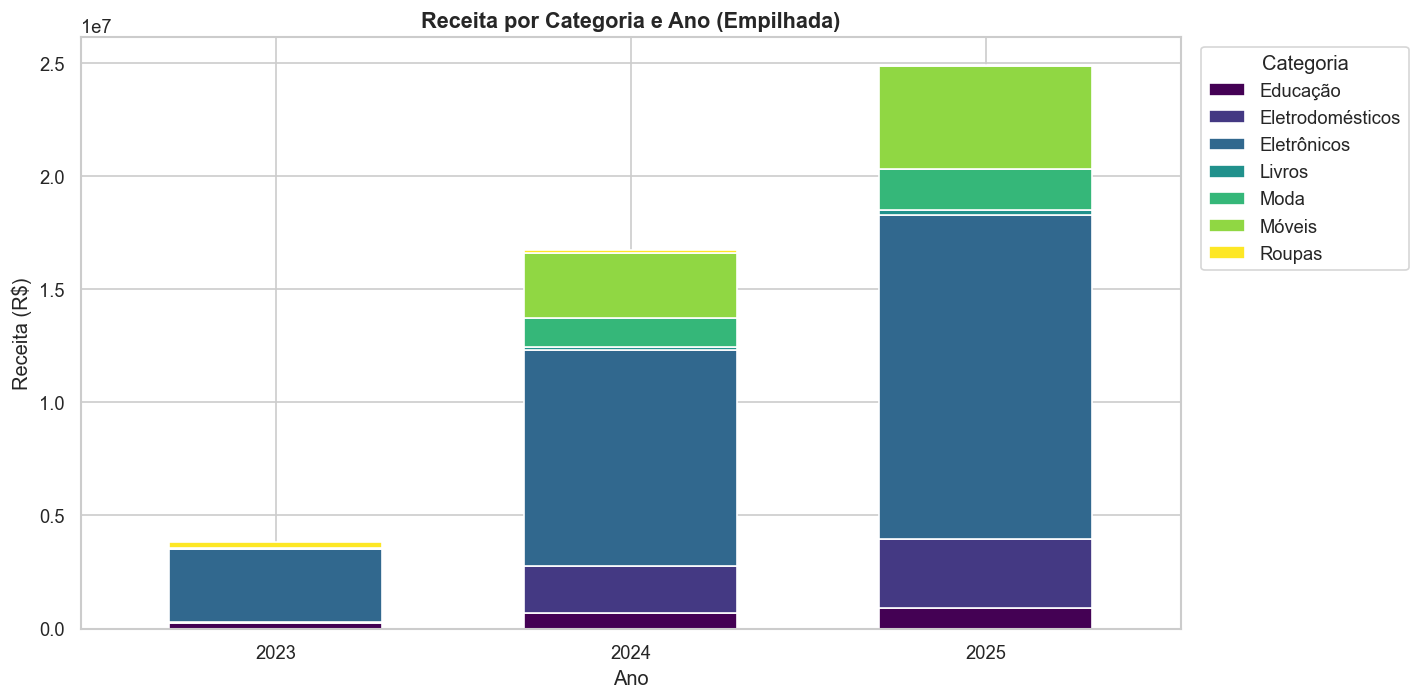

In [18]:
cat_ano = (
    df.groupby(['Ano', 'Categoria'])['Valor_Total_Corrigido']
    .sum()
    .reset_index()
    .pivot(index='Ano', columns='Categoria', values='Valor_Total_Corrigido')
    .fillna(0)
)

############################################
# Gráfico de Barras Empilhadas
############################################
cat_ano.plot(kind='bar', 
             stacked=True,
             figsize=(12,6),
             colormap='viridis',
             width=0.6
            )
plt.title('Receita por Categoria e Ano (Empilhada)')
plt.xlabel('Ano')
plt.ylabel('Receita (R$)')
plt.xticks(rotation=0)
plt.legend(title='Categoria', bbox_to_anchor=(1.01,1), loc="upper left")
plt.tight_layout()
plt.show()

---
**Análise — Receita por Categoria e Ano**

O gráfico empilhado permite observar não apenas o crescimento total da receita,
mas como cada categoria evoluiu individualmente ao longo dos anos:

- **Eletrônicos** foi a categoria que mais cresceu em termos absolutos, sendo a principal
responsável pelo salto de receita entre 2023 e 2024. Sua fatia já era dominante em 2023
e se manteve assim nos anos seguintes, reforçando a dependência do negócio nessa categoria.

- **Móveis** ganhou representatividade visível a partir de 2024, tornando-se a segunda
maior fatia em 2025 — o que sugere um crescimento acelerado dessa categoria no período
mais recente.

- **Eletrodomésticos** também apresentou crescimento consistente, mantendo sua posição
como terceira categoria em todos os anos.

- As demais categorias — Moda, Educação, Roupas e Livros — cresceram em volume absoluto
acompanhando o crescimento geral da operação, mas suas participações relativas permaneceram
pequenas, praticamente invisíveis no gráfico empilhado.

De forma geral, o mix de categorias se manteve estável ao longo do período — o crescimento
foi broad-based, ou seja, todas as categorias cresceram, mas sem alteração significativa
na composição do portfólio.

---
# 07 - Análise por Produto

Identificação dos produtos mais relevantes em receita e volume.

## 07.1 - Top 10 Produtos

In [19]:
prod_receita = (
    df.groupby(['Produto', 'Categoria'])
    .agg(
        Receita=('Valor_Total_Corrigido', 'sum'),
        Transacoes=('id_registro', 'count'),
        Preco_Medio=('Preço Unitário', 'mean')
    )
    .sort_values('Receita', ascending=False)
    .reset_index()
)

prod_receita['Participacao_%'] = (prod_receita['Receita'] / prod_receita['Receita'].sum() * 100).round(2)
top10 = prod_receita.head(10)

print("Top 10 Produtos por Receita:")
print(top10[['Produto', 'Categoria', 'Receita', 'Participacao_%', 'Transacoes']].to_string(index=False))

Top 10 Produtos por Receita:
     Produto   Categoria      Receita  Participacao_%  Transacoes
Smartphone P Eletrônicos 2388215.9024            5.26         282
   Monitor R Eletrônicos 2159829.0328            4.75         276
   Monitor W Eletrônicos 2158629.7460            4.75         277
Smartphone N Eletrônicos 2118003.1944            4.66         272
   Monitor Q Eletrônicos 2099453.3860            4.62         273
Smartphone L Eletrônicos 2025671.0085            4.46         263
  Notebook H Eletrônicos 2018328.8916            4.44         257
      Fone X Eletrônicos 2012608.8268            4.43         245
  Notebook S Eletrônicos 1990127.0358            4.38         255
      Fone C Eletrônicos 1986281.8518            4.37         446


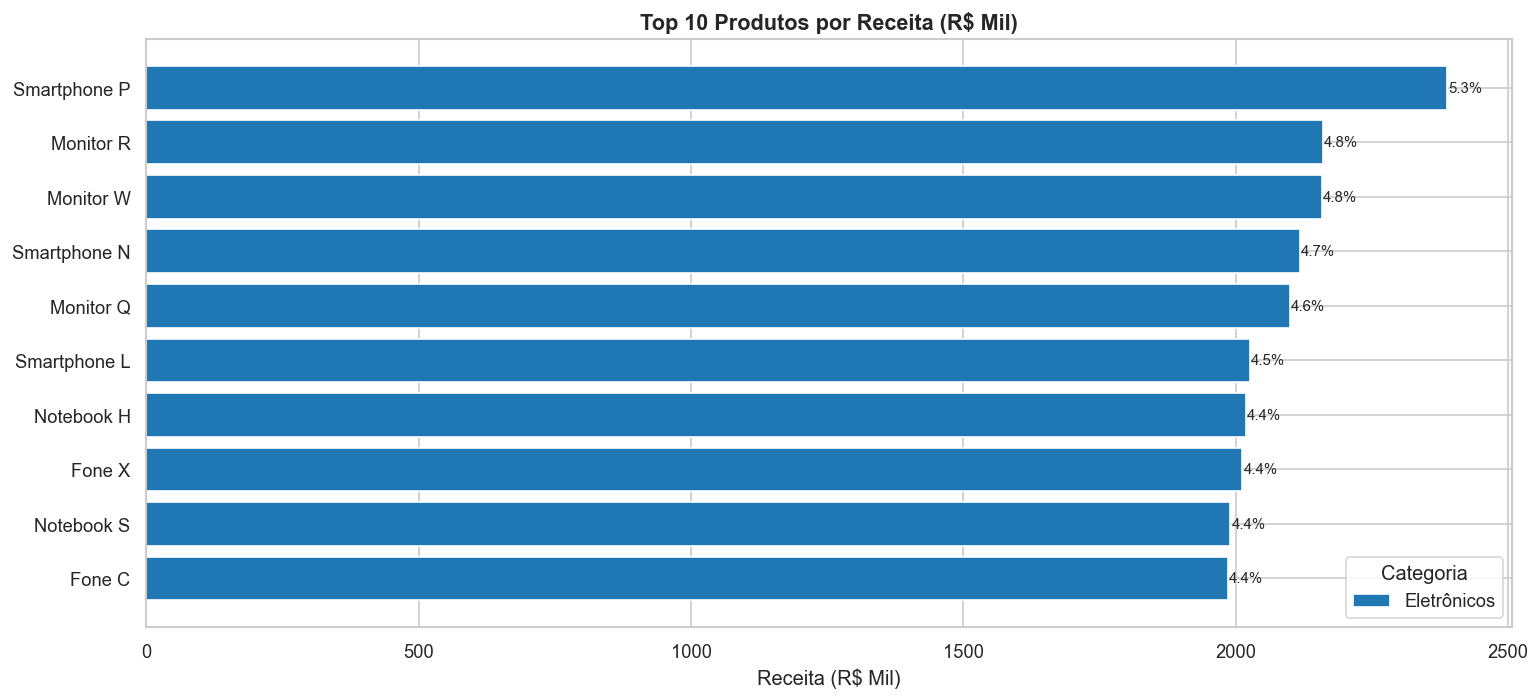

In [20]:
fig, ax = plt.subplots(figsize=(13, 6))
palette = sns.color_palette('tab10', top10['Categoria'].nunique())
cat_color = {cat: palette[i] for i, cat in enumerate(top10['Categoria'].unique())}
colors_bar = [cat_color[c] for c in top10['Categoria']]


############################################
# Gráfico de Barras Horizontais
############################################
bars = ax.barh(top10['Produto'], top10['Receita'] / 1e3, color=colors_bar)
ax.set_title('Top 10 Produtos por Receita (R$ Mil)')
ax.set_xlabel('Receita (R$ Mil)')
ax.invert_yaxis()

# Rótulo de Dados
for bar, pct in zip(bars, top10['Participacao_%']):
    ax.text(bar.get_width() + 2,
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%',
            va='center',
            fontsize=9)

legends_elements = [Patch(facecolor=cat_color[c], label=c) for c in cat_color]
ax.legend(handles=legends_elements, title='Categoria', loc='lower right')
plt.tight_layout()
plt.show()

---
**Análise — Top 10 Produtos por Receita**

O ranking dos 10 produtos mais rentáveis reforça e aprofunda o que já foi observado
na análise por categoria:

- **Todos os 10 produtos pertencem exclusivamente à categoria Eletrônicos**, confirmando
a dominância dessa categoria não apenas em nível agregado, mas também no nível individual
de produto.

- **Smartphone P** lidera com aproximadamente 2,4 milhões de reais em receita e 5,3% de
participação no total. Em seguida aparecem **Monitor R** e **Monitor W** empatados com
4,8% cada, seguidos de **Smartphone N** (4,7%) e **Monitor Q** (4,6%).

- As participações individuais são bastante equilibradas, variando entre 4,3% e 5,3%,
o que indica que não há um único produto dominante — o portfólio de Eletrônicos é
composto por múltiplos produtos de alto desempenho semelhante.

- Um ponto de atenção é o **Fone C**, que aparece em 10° lugar em receita mas lidera
em número de transações (**446**), bem acima dos demais. Isso sugere que é um produto
de ticket menor e alto giro, com um perfil de venda distinto dos outros itens do ranking.

> **Observação:** a ausência de produtos de outras categorias no Top 10 reforça o risco
> de concentração já identificado — nenhum produto de Móveis, Eletrodomésticos ou demais
> categorias chega perto do volume de receita gerado pelos produtos de Eletrônicos.

## 07.2 - Curva de Pareto dos Produtos

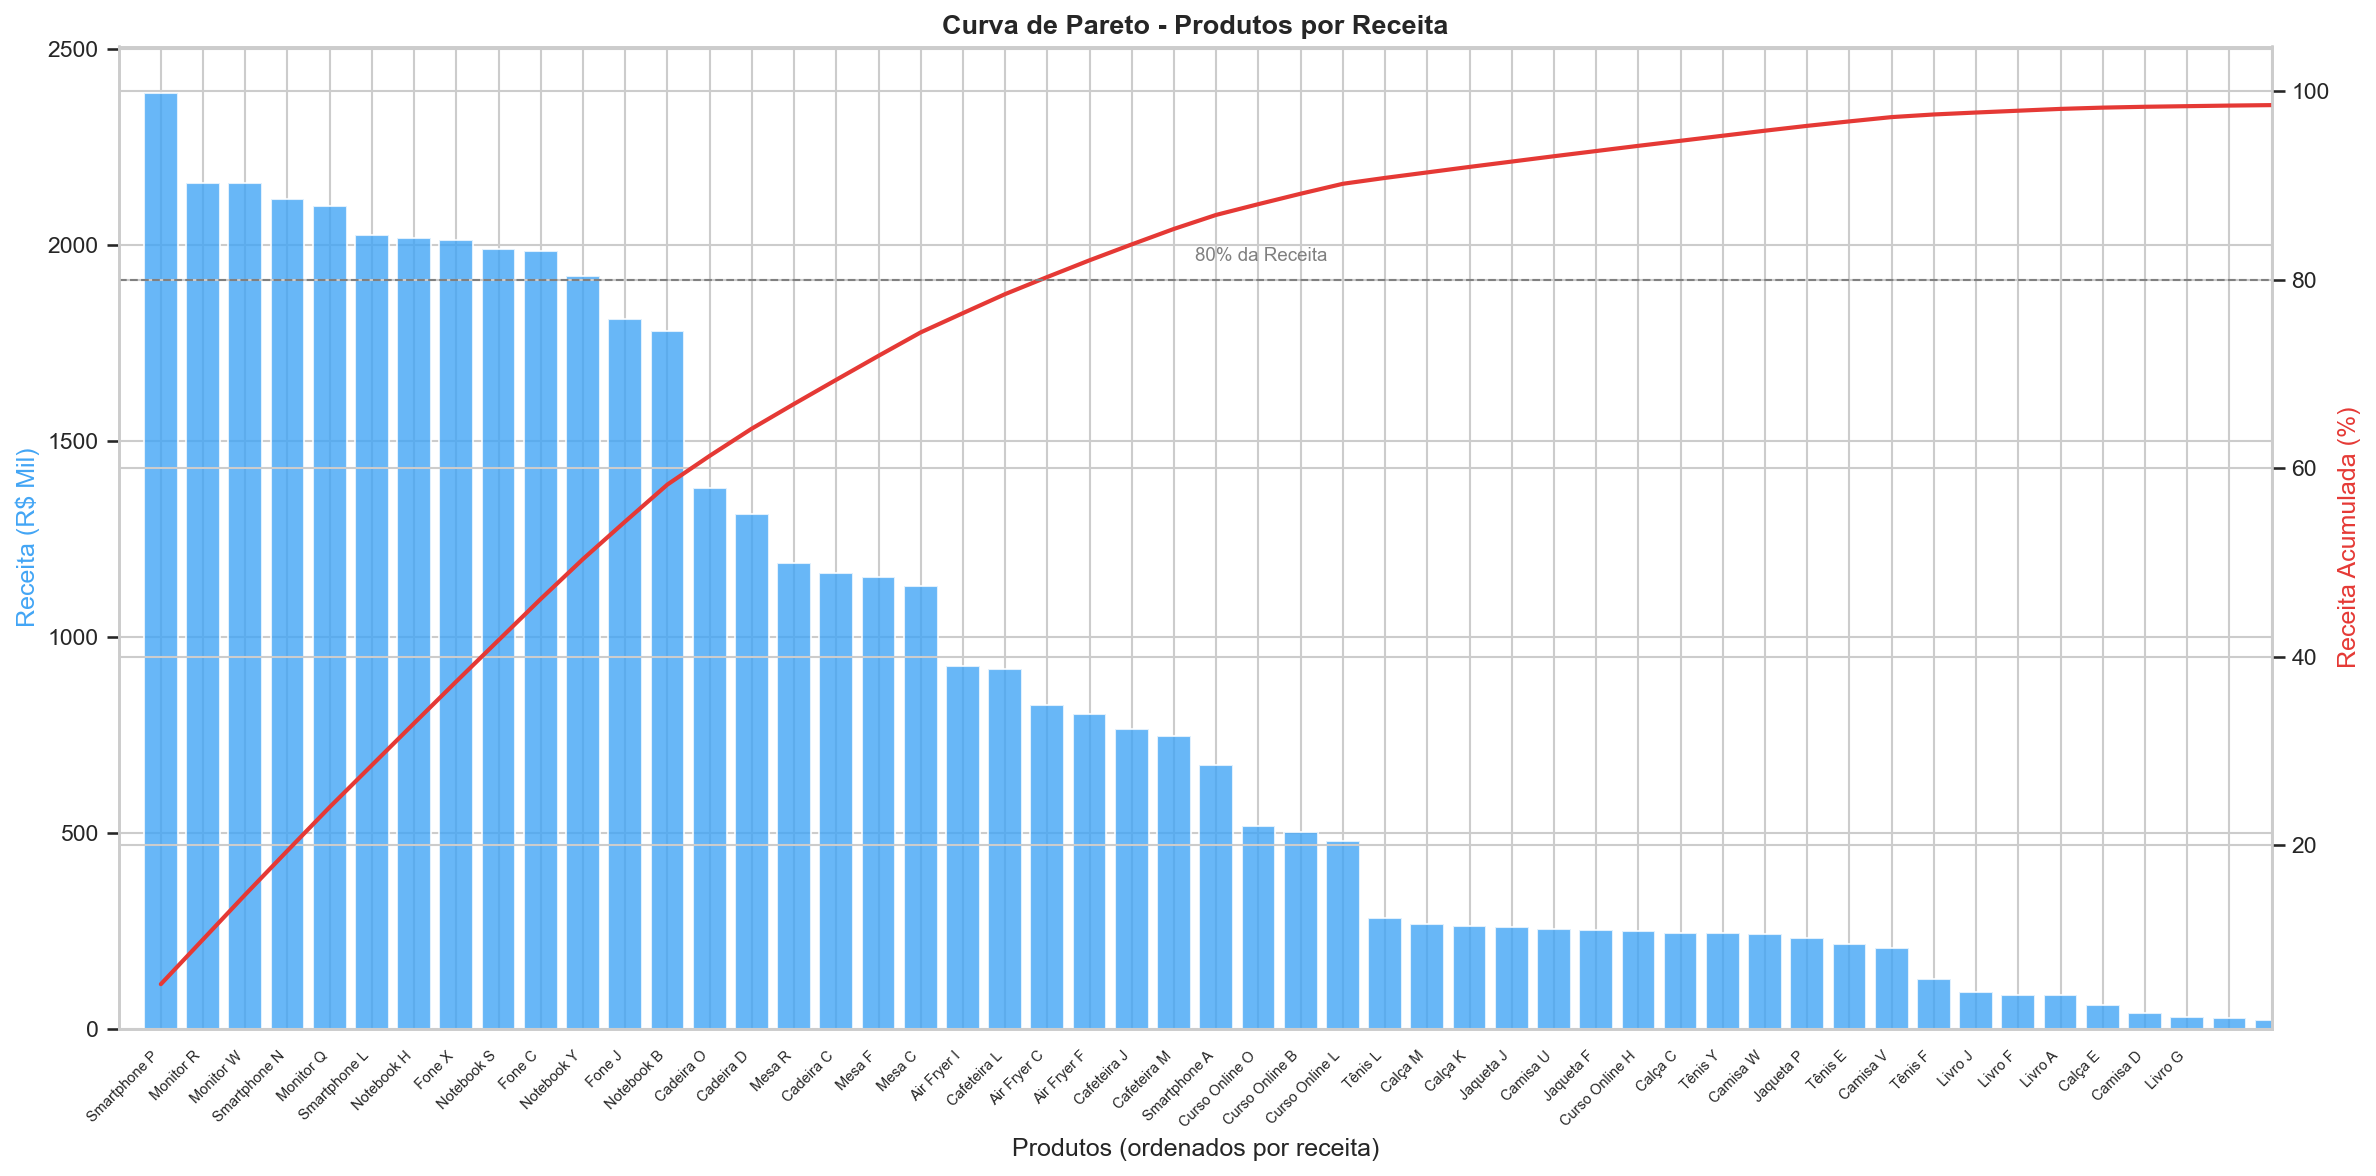


22 produtos representam 80% da receita total (11% do porrfólio).


In [37]:
prod_pareto = prod_receita.copy()
prod_pareto['Receita_Acum_%'] = prod_pareto['Receita'].cumsum() / prod_pareto['Receita'].sum() * 100

fig, ax1 = plt.subplots(figsize=(16, 8), dpi=150)
ax2 = ax1.twinx()

top_n= 49

############################################
# Gráfico 1
############################################
ax1.bar(range(len(prod_pareto)),
        prod_pareto['Receita'] / 1e3,
        color='#42A5F5',
        alpha=0.8)
ax1.set_title('Curva de Pareto - Produtos por Receita')
ax1.set_xlabel('Produtos (ordenados por receita)')
ax1.set_ylabel('Receita (R$ Mil)', color='#42A5F5')
ax1.set_xticks(range(len(prod_pareto)))
labels = list(prod_pareto['Produto'].iloc[:top_n]) + [''] * (len(prod_pareto) - top_n)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax1.set_xlim(-1, 50)
############################################
# Gráfico 2
############################################
ax2.plot(range(len(prod_pareto)),
         prod_pareto['Receita_Acum_%'],
         color='#E53935',
         linewidth=2)
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.text(0.5, 82, '80% da Receita', color='gray', fontsize=9,
         transform=ax2.get_yaxis_transform())
ax2.set_ylabel('Receita Acumulada (%)', color='#E53935')

plt.tight_layout()
plt.show()

n_80 = (prod_pareto['Receita_Acum_%'] <= 80).sum() + 1
print(f'\n{n_80} produtos representam 80% da receita total ({n_80/len(prod_pareto):.0%} do porrfólio).')

---
# 08 - Análise por Forma de Pagamento

Avaliação do comportamento de compra segundo o meio de pagamento utilizado.

 ## 08.1 - Receita, Ticket Médio e Desconto

In [22]:
pag_analise = (
    df.groupby('Forma de Pagamento')
    .agg(
        Receita=('Valor_Total_Corrigido', 'sum'),
        Transacoes=('id_registro', 'count'),
        Ticket_Medio=('Valor_Total_Corrigido', 'mean'),
        Desconto_Medio=('Desconto', 'mean')
    )
    .sort_values('Receita', ascending=False)
    .reset_index()
)

pag_analise['Participacao_%'] = (pag_analise['Receita'] / pag_analise['Receita'].sum() * 100).round(1)
pag_analise['Ticket_fmt']     = pag_analise['Ticket_Medio'].apply(fmt_brl)
pag_analise['Desconto_fmt']   = pag_analise['Desconto_Medio'].map('{:.1%}'.format)

print(pag_analise[['Forma de Pagamento', 'Participacao_%', 'Transacoes', 'Ticket_fmt', 'Desconto_fmt']].to_string(index=False))

Forma de Pagamento  Participacao_%  Transacoes  Ticket_fmt Desconto_fmt
 Cartão de Crédito            27.5        3537 R$ 3.526,85         9.2%
               Pix            24.7        3178 R$ 3.529,92         9.7%
  Cartão de Débito            24.2        3125 R$ 3.521,98         9.7%
            Boleto            23.6        2927 R$ 3.667,29         9.9%


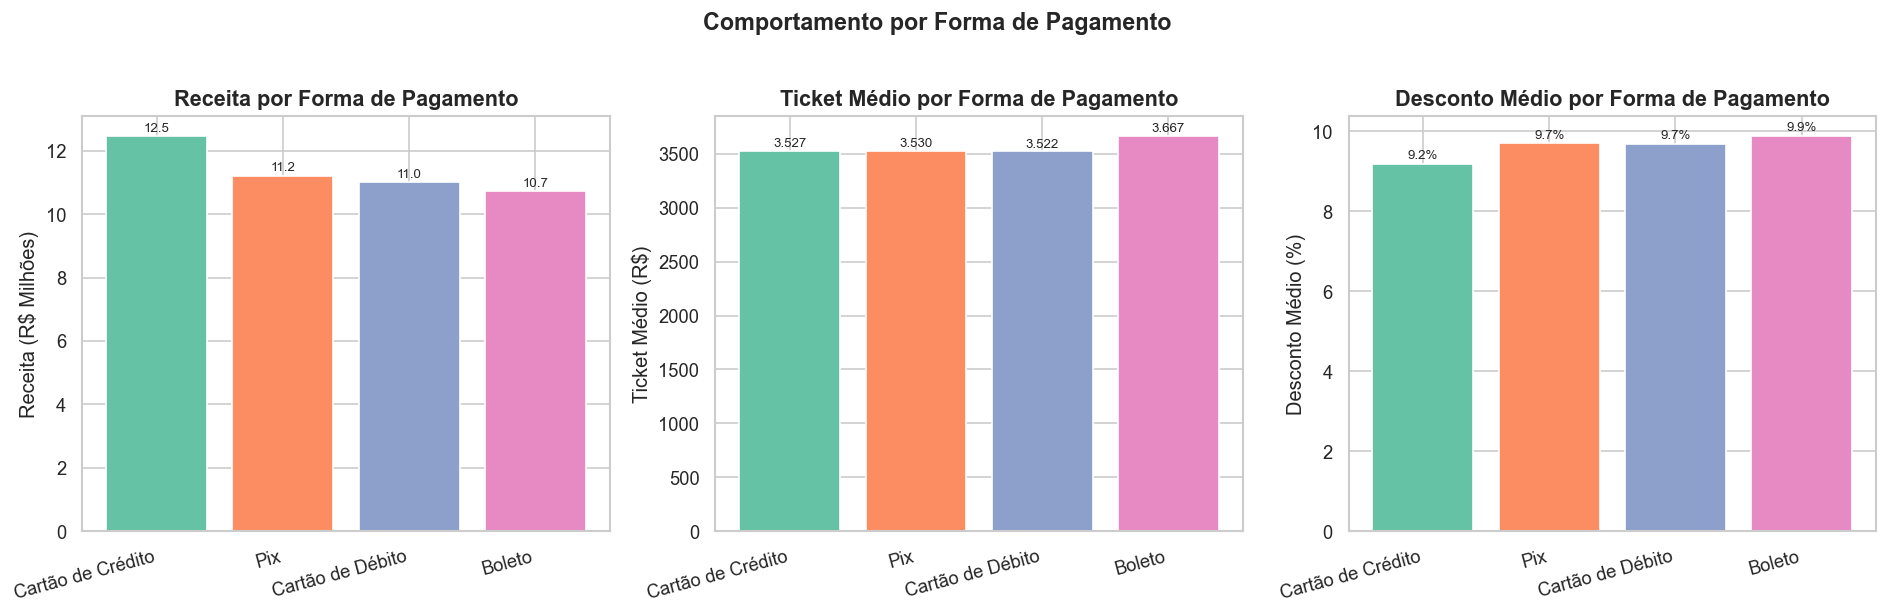

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = sns.color_palette('Set2', 4)


###########################################
# Gráfico 1 - Gráfico de Barras - Receita
###########################################
bars0 = axes[0].bar(pag_analise['Forma de Pagamento'], pag_analise['Receita'] / 1e6, color=palette)
axes[0].set_title('Receita por Forma de Pagamento')
axes[0].set_ylabel('Receita (R$ Milhões)')
axes[0].set_xticklabels(pag_analise['Forma de Pagamento'], rotation=15, ha='right')

# Rótulo de Dados
for bar, val in zip(bars0, pag_analise['Receita']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.05,
                 f'{val/1e6:.1f}',
                 ha='center', va='bottom', fontsize=8)

    
###############################################
# Gráfico 2 - Gráfico de Barras - Ticket Médio
###############################################
bars1 = axes[1].bar(pag_analise['Forma de Pagamento'], pag_analise['Ticket_Medio'], color=palette)
axes[1].set_title('Ticket Médio por Forma de Pagamento')
axes[1].set_ylabel('Ticket Médio (R$)')
axes[1].set_xticklabels(pag_analise['Forma de Pagamento'], rotation=15, ha='right')

# Rótulo de Dados
for bar, val in zip(bars1, pag_analise['Ticket_Medio']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 10,
                 f'{val:,.0f}'.replace(',', '.'),
                 ha='center', va='bottom', fontsize=8)

    
##################################################
# Gráfico 3 - Gráfico de Barras - Desconto Médio
##################################################
bars2 = axes[2].bar(pag_analise['Forma de Pagamento'], pag_analise['Desconto_Medio'] * 100, color=palette)
axes[2].set_title('Desconto Médio por Forma de Pagamento')
axes[2].set_ylabel('Desconto Médio (%)')
axes[2].set_xticklabels(pag_analise['Forma de Pagamento'], rotation=15, ha='right')

# Rótulo de Dados
for bar, val in zip(bars2, pag_analise['Desconto_Medio']):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.05,
                 f'{val*100:.1f}%',
                 ha='center', va='bottom', fontsize=8)

plt.suptitle('Comportamento por Forma de Pagamento', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
**Análise — Comportamento por Forma de Pagamento**

As quatro formas de pagamento apresentam distribuição bastante equilibrada em todos
os indicadores analisados:

- **Receita:** a participação é praticamente uniforme entre os meios de pagamento,
variando entre 23,6% (Boleto) e 27,5% (Cartão de Crédito). Não há dominância
expressiva de nenhum meio de pagamento no faturamento total.

- **Ticket Médio:** as diferenças são pequenas mas observáveis. Boleto apresenta o
maior ticket médio (3.667 reais), seguido de Cartão de Crédito (3.526 reais),
Pix (3.529 reais) e Cartão de Débito (3.521 reais). A variação entre o maior e
o menor ticket é de apenas ~4%, o que sugere que a forma de pagamento não é um
fator determinante no valor da compra.

- **Desconto Médio:** também bastante uniforme, entre 9,2% (Cartão de Crédito) e
9,9% (Boleto), sem variação significativa entre os meios.

De forma geral, os dados indicam que o comportamento de compra é homogêneo entre
as formas de pagamento — não há evidência de que clientes que pagam com um
determinado meio realizem compras de valor significativamente maior ou menor.
Essa hipótese será testada estatisticamente no próximo notebook.

## 08.2 - Distribuição do Ticket por Forma de Pagamento (Boxplot)

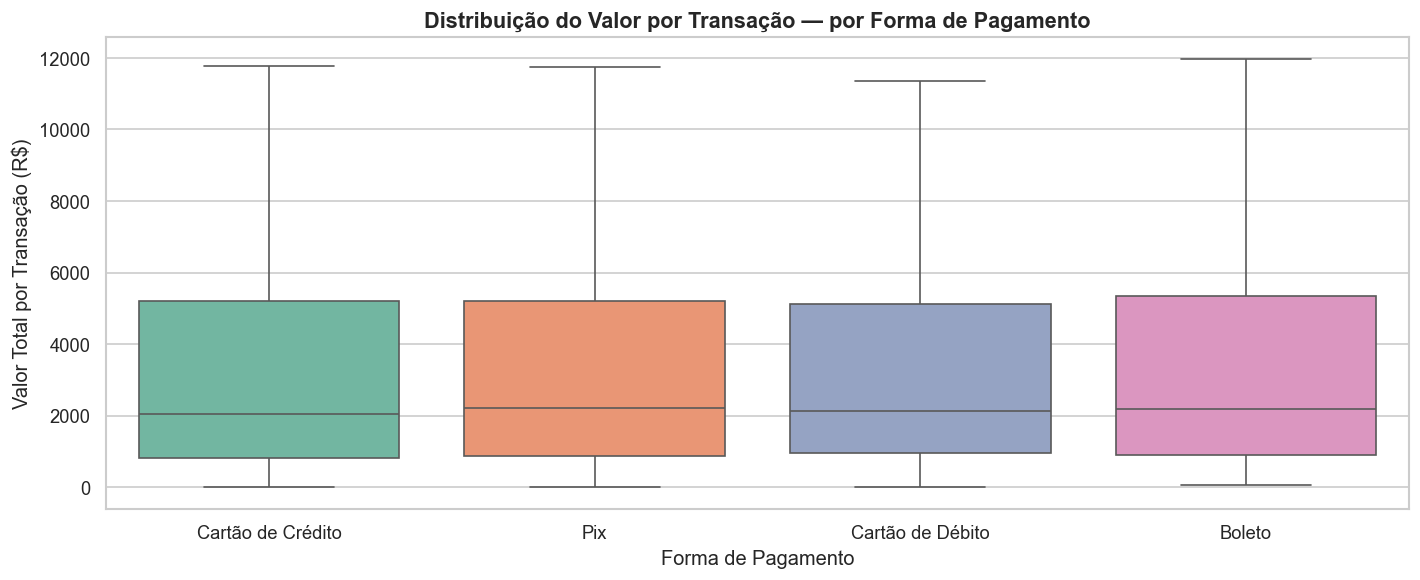

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))
ordem = pag_analise['Forma de Pagamento'].tolist()
sns.boxplot(
    data=df,
    x='Forma de Pagamento',
    y='Valor_Total_Corrigido',
    order=ordem,
    palette='Set2',
    showfliers=False,
    ax=ax
)
ax.set_title('Distribuição do Valor por Transação — por Forma de Pagamento')
ax.set_xlabel('Forma de Pagamento')
ax.set_ylabel('Valor Total por Transação (R$)')
plt.tight_layout()
plt.show()

---
**Análise — Distribuição do Valor por Transação por Forma de Pagamento**

O boxplot complementa a análise anterior e confirma o comportamento homogêneo
entre os meios de pagamento, agora sob a perspectiva da distribuição completa
dos valores:

- **Mediana:** todas as formas de pagamento apresentam mediana em torno de 2.000 reais,
sem diferença visível entre elas — reforçando que o valor típico de compra é
independente do meio de pagamento escolhido.

- **Amplitude interquartil (IQR):** as caixas são praticamente do mesmo tamanho em
todos os grupos, variando aproximadamente entre 500 e 5.000 reais, o que indica
dispersão semelhante entre os meios.

- **Valores máximos:** todos os meios atingem valores máximos entre 11.000 e 12.000
reais, sem que nenhum se destaque como meio preferencial para compras de alto valor.

A uniformidade visual entre os quatro boxplots é em si uma informação relevante —
ela sugere que a escolha do meio de pagamento não está associada ao perfil de gasto
do cliente. Essa ausência de diferença será formalmente testada através de um teste
estatístico no próximo notebook.

# 09 - Análise Geográfica

 ## 09.1 - Performance por Cidade

In [25]:
geo = (
    df.groupby('Localização')
    .agg(
        Receita=('Valor_Total_Corrigido', 'sum'),
        Transacoes=('id_registro', 'count'),
        Ticket_Medio=('Valor_Total_Corrigido', 'mean')
    )
    .sort_values('Receita', ascending=False)
    .reset_index()
)

geo['Participacao_%'] = (geo['Receita'] / geo['Receita'].sum() * 100).round(1)
print(geo[['Localização', 'Receita', 'Participacao_%', 'Transacoes', 'Ticket_Medio']].to_string(index=False))

   Localização      Receita  Participacao_%  Transacoes  Ticket_Medio
     São Paulo 5020879.2253            11.1        1468   3420.217456
Rio De Janeiro 4504241.9685             9.9        1314   3427.885821
Belo Horizonte 4053881.3284             8.9        1158   3500.761078
      Salvador 4019885.1767             8.8        1132   3551.135315
      Curitiba 3809944.9282             8.4        1137   3350.875047
       Goiânia 3585853.8024             7.9         967   3708.225235
      Brasília 3505442.8616             7.7         936   3745.131262
  Porto Alegre 3486392.3054             7.7         939   3712.877855
        Recife 3454394.2014             7.6         955   3617.166703
     Fortaleza 3408506.5072             7.5         924   3688.859856
      Campinas 3310181.3992             7.3         928   3567.005818
 Florianópolis 3273314.0156             7.2         909   3601.005518


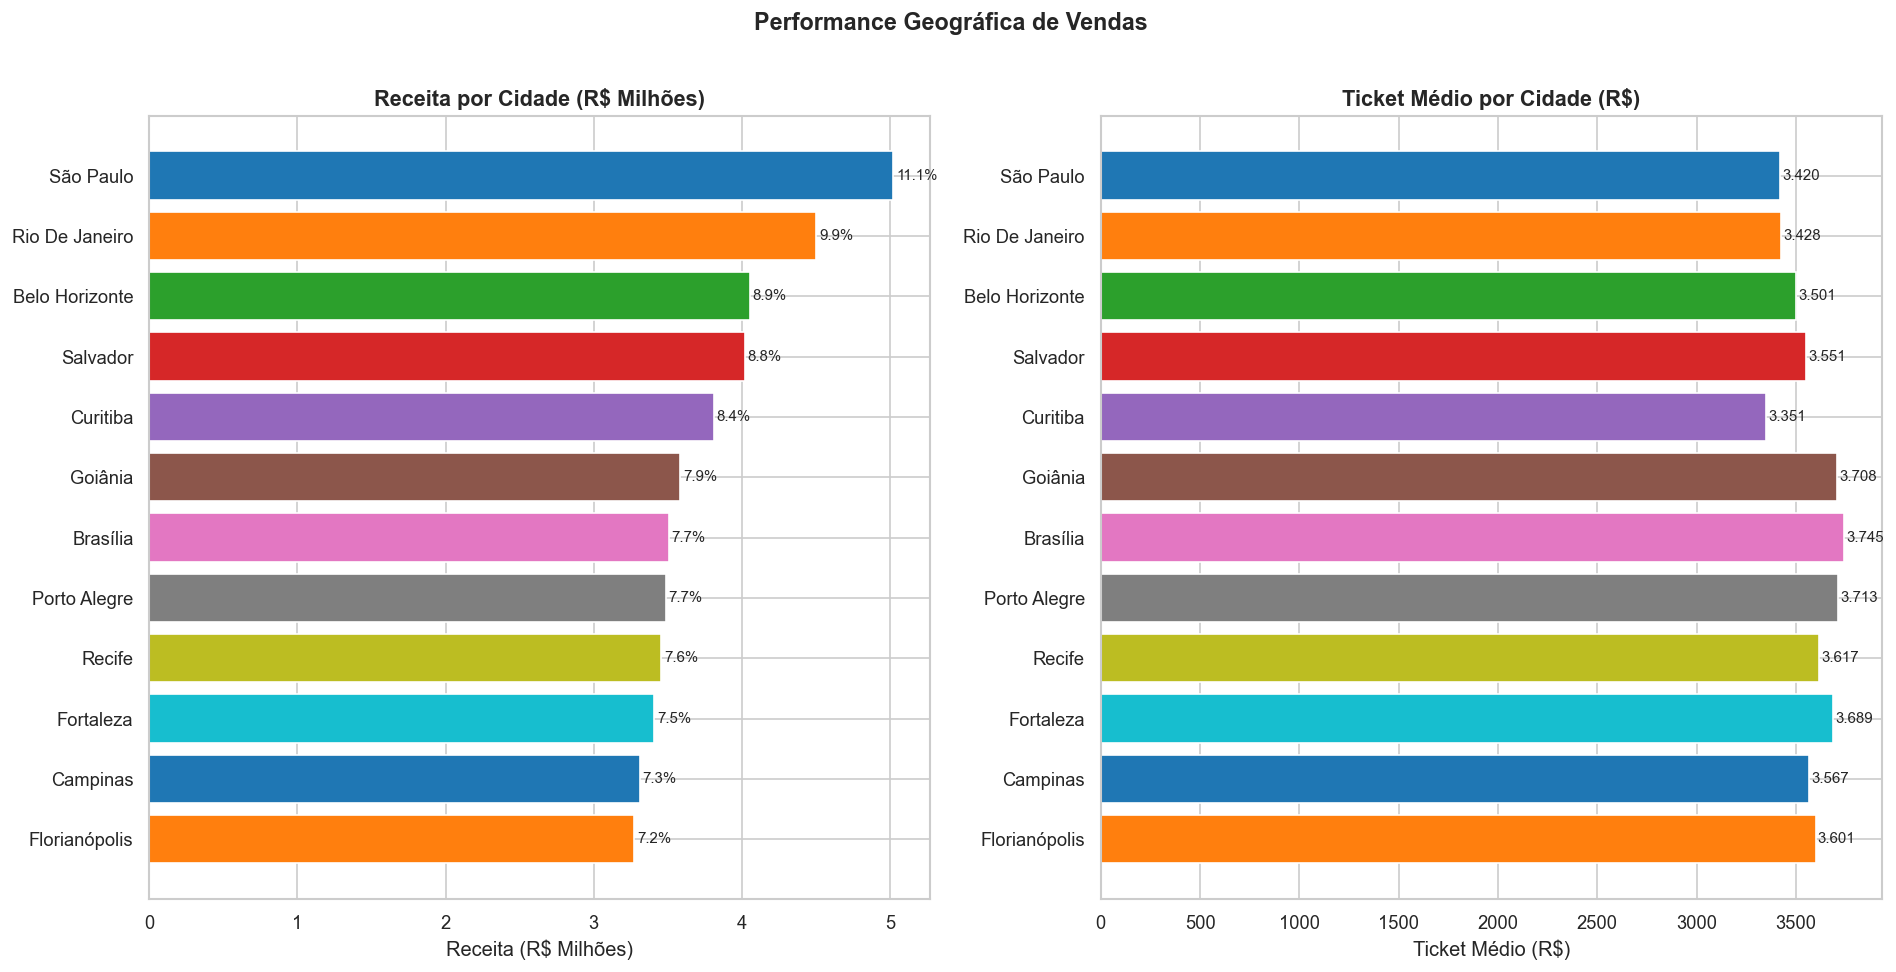

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
cores_geo = sns.color_palette('tab10', len(geo))

######################################################
# Gráfico 1 - Barras Horizontais - Receita por Cidade
#######################################################
bars0 = axes[0].barh(geo['Localização'], geo['Receita'] / 1e6, color=cores_geo)
axes[0].set_title('Receita por Cidade (R$ Milhões)')
axes[0].set_xlabel('Receita (R$ Milhões)')
axes[0].invert_yaxis()

# Rótulo de Dados
for bar, pct in zip(bars0, geo['Participacao_%']):
    axes[0].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
                 f'{pct}%', va='center', fontsize=9)


############################################################
# Gráfico 1 - Barras Horizontais - Ticket Médio por Cidade
############################################################
bars1 = axes[1].barh(geo['Localização'], geo['Ticket_Medio'], color=cores_geo)
axes[1].set_title('Ticket Médio por Cidade (R$)')
axes[1].set_xlabel('Ticket Médio (R$)')
axes[1].invert_yaxis()

# Rótulo de Dados
for bar, val in zip(bars1, geo['Ticket_Medio']):
    axes[1].text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
                 f'{val:,.0f}'.replace(',', '.'),
                 va='center', fontsize=9)

plt.suptitle('Performance Geográfica de Vendas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
**Análise — Performance Geográfica de Vendas**

A distribuição geográfica revela dois padrões distintos: concentração de receita nas grandes capitais e variação relevante no ticket médio entre as cidades.

**Receita por Cidade:**
- São Paulo lidera com 11,1% da receita total, seguida de Rio de Janeiro (9,9%) e Belo Horizonte (8,9%). Juntas, essas três cidades concentram aproximadamente 30% do faturamento.
- A distribuição entre as demais cidades é bastante equilibrada, variando entre 7,2% (Florianópolis) e 8,8% (Salvador), sem concentração excessiva em nenhuma região específica.

**Ticket Médio por Cidade:**
- Aqui o padrão se inverte de forma interessante — as cidades com maior receita não são necessariamente as de maior ticket médio.
- Brasília (3.745 reais) e Goiânia (3.708 reais) lideram no ticket médio, apesar de ocuparem posições intermediárias em receita. Isso indica que os clientes dessas cidades realizam compras de maior valor individual.
- São Paulo, apesar de liderar em receita, apresenta o menor ticket médio (3.420 reais) — seu volume de faturamento é sustentado pela quantidade de transações, não pelo valor médio de cada compra.
- Curitiba também chama atenção negativamente, com o segundo menor ticket médio (3.351 reais) mesmo sendo a quinta cidade em receita.

Essa combinação de receita e ticket médio por cidade pode orientar estratégias diferenciadas: em São Paulo e Rio de Janeiro o foco pode ser manter o volume, enquanto em Brasília e Goiânia há potencial para explorar produtos de maior valor agregado.

## 09.2 - Mix de Categorias por Cidade

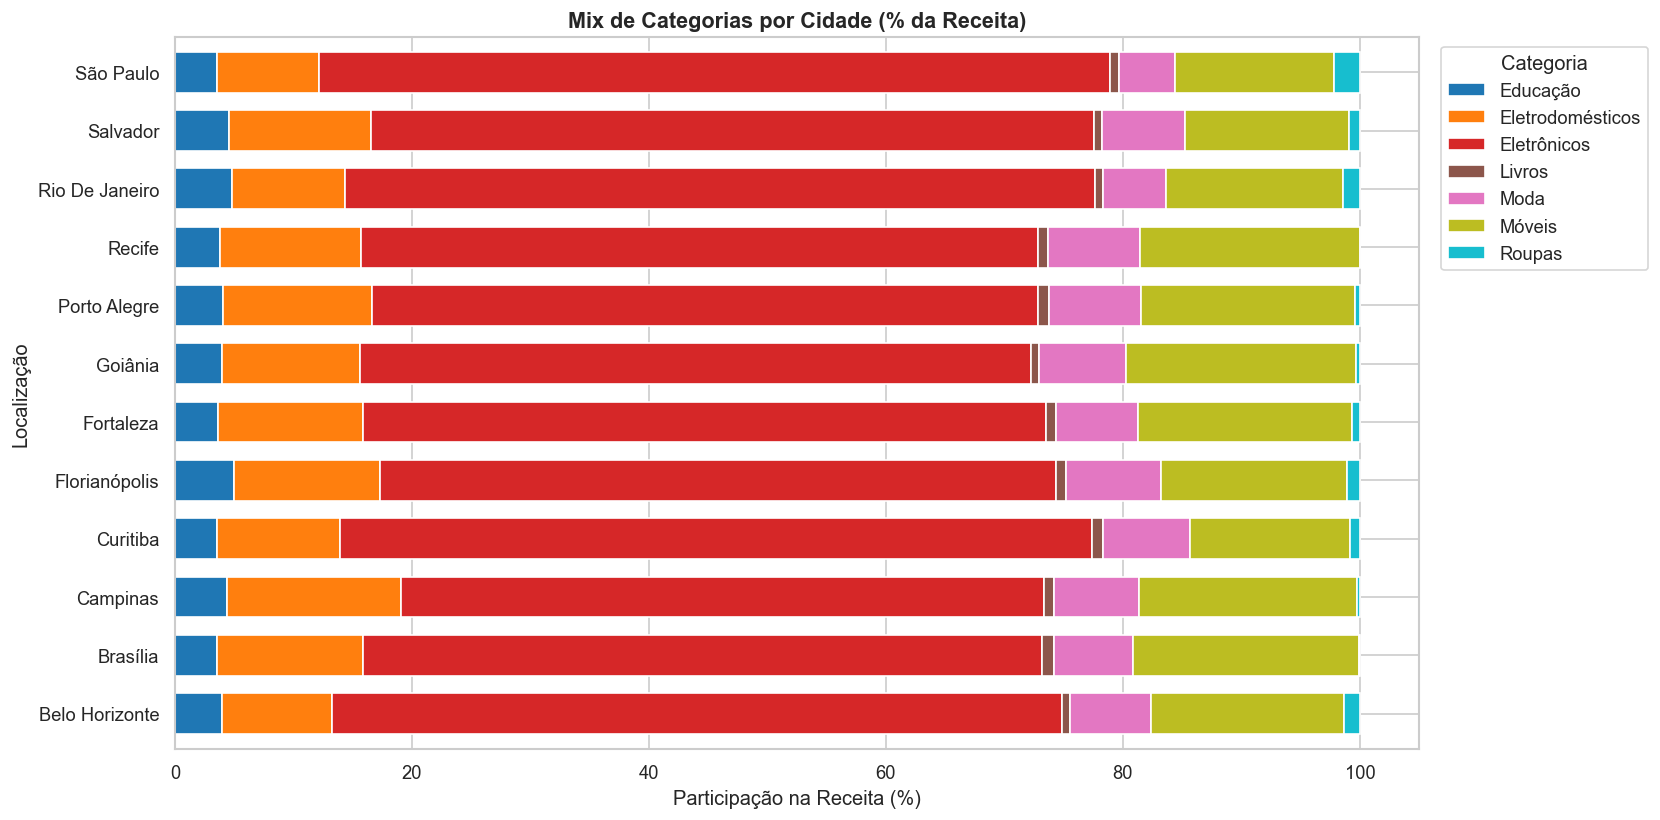

In [27]:
geo_cat = (
    df.groupby(['Localização', 'Categoria'])['Valor_Total_Corrigido']
    .sum()
    .reset_index()
    .pivot(index='Localização', columns='Categoria', values='Valor_Total_Corrigido')
    .fillna(0)
)

geo_cat_norm = geo_cat.div(geo_cat.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
geo_cat_norm.plot(kind='barh', stacked=True, ax=ax, colormap='tab10', width=0.7)
ax.set_title('Mix de Categorias por Cidade (% da Receita)')
ax.set_xlabel('Participação na Receita (%)')
ax.legend(title='Categoria', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
**Análise — Mix de Categorias por Cidade**

O gráfico revela que o mix de categorias é notavelmente homogêneo entre todas as cidades, com Eletrônicos dominando em todas elas:

- **Eletrônicos** representa entre 55% e 65% da receita em praticamente todas as cidades, sem exceção. Não há nenhuma cidade onde essa categoria não seja amplamente dominante.

- **Móveis** aparece como segunda categoria em todas as cidades, ocupando aproximadamente 15% a 20% da receita, seguido de **Eletrodomésticos** com participação similar.

- **Moda, Educação, Livros e Roupas** têm participações residuais e uniformes em todas as regiões, praticamente invisíveis no gráfico.

- A única variação perceptível entre as cidades está em **Recife e Porto Alegre**, que apresentam uma fatia ligeiramente menor de Eletrônicos e maior de Móveis em comparação com São Paulo e Salvador.

De forma geral, o mix de categorias não apresenta heterogeneidade regional relevante — o comportamento de compra por categoria é consistente independentemente da cidade. Isso indica que a operação tem um perfil de demanda uniforme nacionalmente, sem necessidade imediata de estratégias de portfólio diferenciadas por região.

---
# 10 - Correlações e Distribuições

Análise das relações entre variáveis numéricas e distribuição dos valores de transação.

## 10.1 - Distribuição do Valor Total por Transação

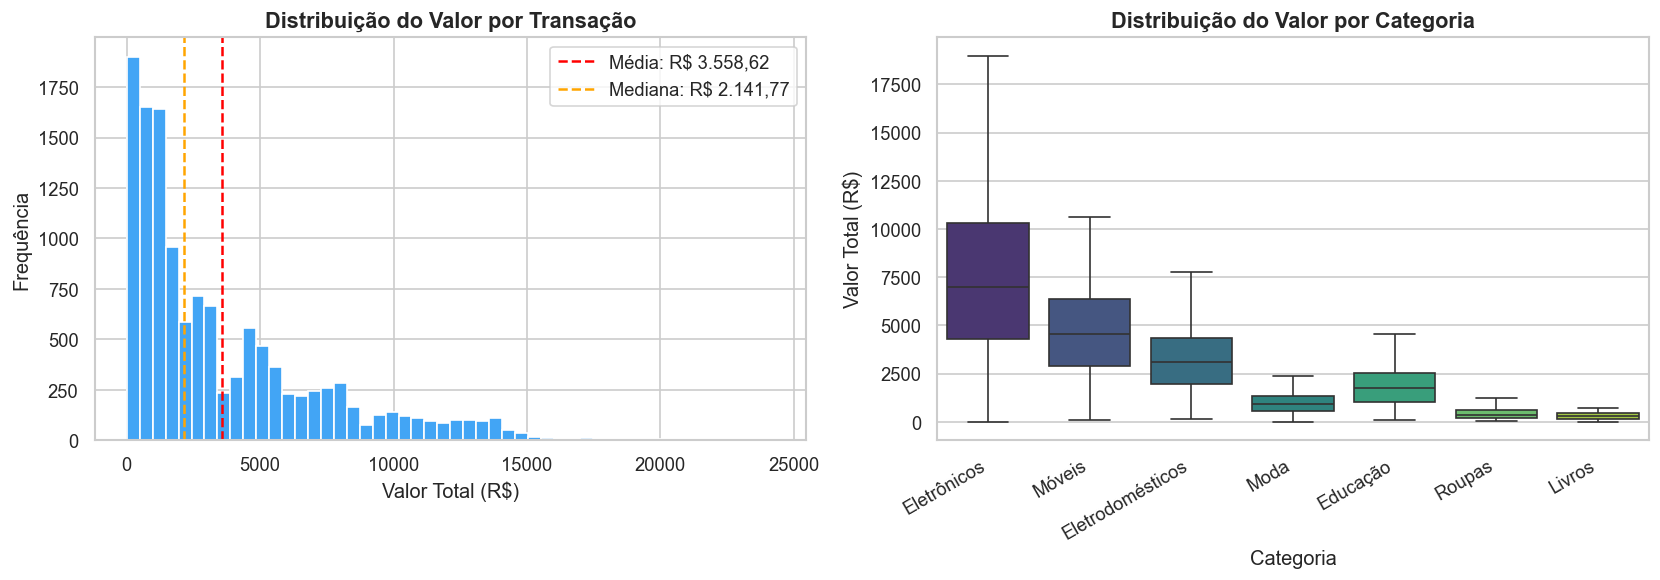

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Valor_Total_Corrigido'], bins=50, color='#42A5F5', edgecolor='white')
axes[0].set_title('Distribuição do Valor por Transação')
axes[0].set_xlabel('Valor Total (R$)')
axes[0].set_ylabel('Frequência')
axes[0].axvline(df['Valor_Total_Corrigido'].mean(), color='red', linestyle='--',
                label=f"Média: {fmt_brl(df['Valor_Total_Corrigido'].mean())}")
axes[0].axvline(df['Valor_Total_Corrigido'].median(), color='orange', linestyle='--',
                label=f"Mediana: {fmt_brl(df['Valor_Total_Corrigido'].median())}")
axes[0].legend()

ordem_cat = cat_receita['Categoria'].tolist()
sns.boxplot(data=df, x='Categoria', y='Valor_Total_Corrigido',
            order=ordem_cat, palette='viridis', showfliers=False, ax=axes[1])
axes[1].set_title('Distribuição do Valor por Categoria')
axes[1].set_xticklabels(ordem_cat, rotation=30, ha='right')
axes[1].set_xlabel('Categoria')
axes[1].set_ylabel('Valor Total (R$)')

plt.tight_layout()
plt.show()

---
**Análise — Distribuição do Valor por Transação**

**Histograma:**
- A distribuição é assimétrica à direita (cauda longa), com a grande maioria das transações concentradas entre 0 e 5.000 reais.
- A mediana (2.142 reais) é significativamente menor que a média (3.559 reais), o que é característico de distribuições com cauda longa — poucas transações de alto valor puxam a média para cima, mas o valor típico de compra é bem mais baixo.
- Isso significa que o ticket médio de 3.559 reais não representa bem o comportamento da maioria dos clientes, sendo a mediana uma métrica mais representativa do valor típico de compra.

**Boxplot por Categoria:**
- **Eletrônicos** apresenta a maior dispersão de valores, com mediana em torno de 7.500 reais e transações chegando a 19.000 reais — reflexo de produtos de alto valor como notebooks, smartphones e monitores.
- **Móveis** tem mediana próxima de 5.000 reais e dispersão considerável, confirmando seu perfil de produto de ticket elevado.
- **Eletrodomésticos** aparece com mediana em torno de 3.000 reais e menor dispersão que as duas categorias anteriores.
- **Moda, Educação, Roupas e Livros** concentram valores significativamente menores, todos abaixo de 2.500 reais na mediana, com pouca dispersão.

A diferença expressiva entre as categorias reforça porque Eletrônicos e Móveis dominam a receita total — não apenas vendem mais, mas vendem por valores unitários muito superiores às demais categorias.

## 10.2 - Matriz de Correlação

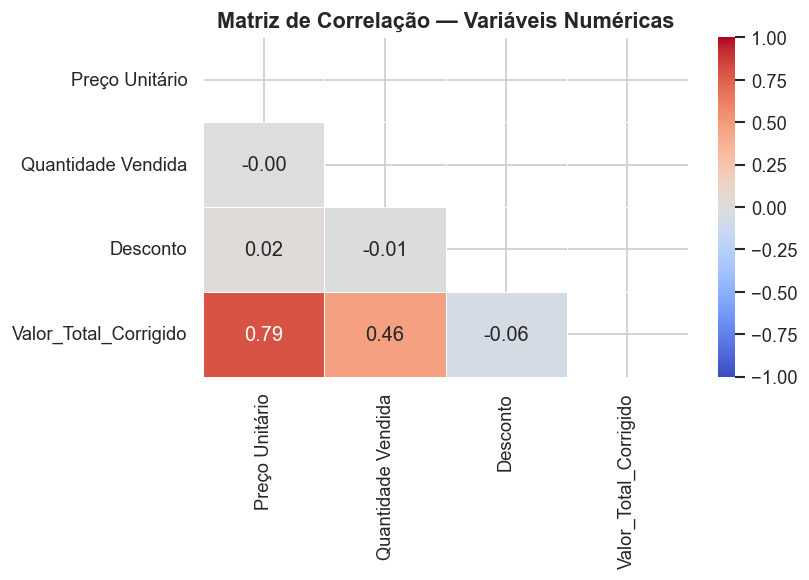

In [29]:
cols_num = ['Preço Unitário', 'Quantidade Vendida', 'Desconto', 'Valor_Total_Corrigido']
corr = df[cols_num].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Matriz de Correlação — Variáveis Numéricas')
plt.tight_layout()
plt.show()

---
**Análise — Matriz de Correlação**

A matriz revela relações importantes entre as variáveis numéricas da base:

- **Preço Unitário × Valor Total (0.79):** correlação forte e positiva — é a relação mais expressiva da matriz. Quanto maior o preço unitário do produto, maior tende a ser o valor total da transação. Isso indica que o faturamento é mais sensível ao valor do produto do que à quantidade vendida.

- **Quantidade Vendida × Valor Total (0.46):** correlação moderada e positiva — a quantidade também influencia o valor total, mas com intensidade menor que o preço unitário. Isso faz sentido dado que a fórmula do Valor Total depende de ambos, mas produtos de alto preço unitário geram valores altos mesmo em pequenas quantidades.

- **Desconto × Valor Total (-0.06):** correlação praticamente inexistente e levemente negativa — o desconto não tem impacto relevante no valor final da transação, o que é coerente com os descontos médios baixos (~9,5%) observados na análise de pagamento.

- **Preço Unitário × Quantidade Vendida (-0.00)** e **Desconto × Quantidade Vendida (-0.01):** correlações nulas, indicando que o preço do produto e o desconto aplicado não influenciam a quantidade comprada por transação.

> **Observação:** a ausência de correlação entre Desconto e Valor Total sugere que a política de descontos atual não está associada a compras de maior valor — ou seja, descontos maiores não estão sendo direcionados a produtos ou transações de ticket mais alto. Isso pode ser um ponto de atenção para a estratégia comercial, a ser investigado no próximo notebook.

## 10.3 - Relação entre Desconto e Valor Total

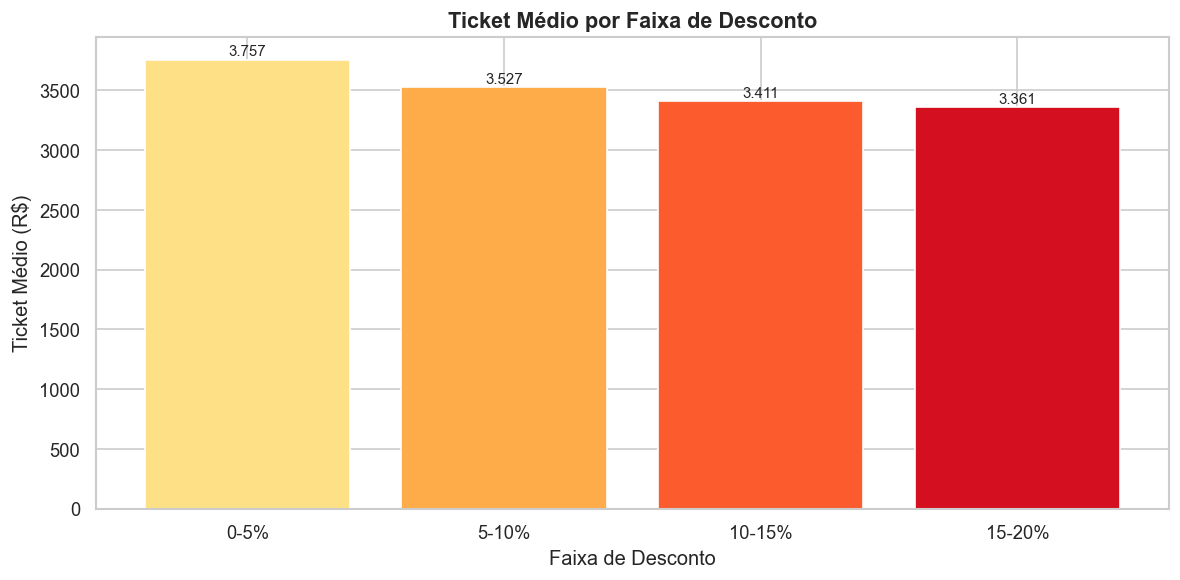

In [34]:
bins = [0, 0.05, 0.10, 0.15, 0.20, 0.25]
labels_desc = ['0-5%', '5-10%', '10-15%', '15-20%', '20-25%']

desc_grupo = (
    df.groupby(pd.cut(df['Desconto'], bins=bins, labels=labels_desc))['Valor_Total_Corrigido']
    .mean()
    .reset_index()
    .rename(columns={'Desconto': 'Faixa', 'Valor_Total_Corrigido': 'Ticket_Medio'})
    .dropna()
)

desc_grupo = desc_grupo[desc_grupo['Ticket_Medio'] > 500]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(desc_grupo['Faixa'].astype(str), desc_grupo['Ticket_Medio'],
              color=sns.color_palette('YlOrRd', len(desc_grupo)))
ax.set_title('Ticket Médio por Faixa de Desconto')
ax.set_xlabel('Faixa de Desconto')
ax.set_ylabel('Ticket Médio (R$)')

for bar, val in zip(bars, desc_grupo['Ticket_Medio']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            f'{val:,.0f}'.replace(',', '.'),
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
**Análise — Ticket Médio por Faixa de Desconto**

O gráfico revela uma relação inversa e consistente entre desconto e ticket médio:

- Transações com desconto entre **0-5%** apresentam o maior ticket médio (3.757 reais), enquanto a faixa **15-20%** registra o menor (3.361 reais).
- A queda é gradual e progressiva a cada faixa: 3.757 → 3.527 → 3.411 → 3.361, sugerindo que quanto maior o desconto aplicado, menor tende a ser o valor final da transação.
- A variação total entre a faixa de menor e maior desconto é de apenas ~11%, o que indica que o impacto do desconto no ticket médio existe mas é modesto.

Esse padrão é coerente com a correlação negativa fraca (-0.06) identificada na matriz de correlação — a relação existe na direção esperada, mas não é forte o suficiente para ser considerada determinante.

> **Observação:** a faixa 20-25% foi removida da visualização por conter apenas 1 transação, sendo estatisticamente irrelevante para análise. A base de descontos está concentrada entre 0% e 20%, o que representa 99,99% das transações.

---
# 11 - Conclusões e Próximos Passos

## Síntese dos Principais Achados

### Receita e Crescimento
- A receita total do período foi de aproximadamente 45,4 milhões de reais, calculada com base no `Valor_Total_Corrigido`, corrigindo a subavaliação de 510 mil reais identificada na etapa de Data Cleaning.
- O crescimento foi expressivo e consistente: de 3,8 milhões em 2023 para 24,9 milhões em 2025, representando crescimento acumulado de ~553% em dois anos.
- A ruptura de patamar em Jan/2024 — com receita saltando de ~300 mil para ~1,4 milhão em um único mês — foi o evento mais relevante da série e merece investigação junto às áreas de negócio.

### Sazonalidade
- A decomposição da série temporal confirmou a existência de sazonalidade, com padrão multiplicativo e tendência de crescimento linear após Jan/2024.
- Fevereiro é consistentemente o mês mais fraco nos três anos, enquanto o segundo semestre de 2025 sinalizou fortalecimento da sazonalidade.
- A sazonalidade ainda é suave e não totalmente consolidada, possivelmente mascarada pelo crescimento acelerado da operação.

### Mix de Categorias e Produtos
- Eletrônicos domina com 59,8% da receita total, seguido de Móveis (16,4%) e Eletrodomésticos (11,3%) — as três categorias concentram 87,5% do faturamento.
- Todos os 10 produtos mais rentáveis pertencem exclusivamente a Eletrônicos, sem nenhuma outra categoria no ranking.
- Apenas 22 produtos (11% do portfólio) respondem por 80% da receita — concentração típica de curva de Pareto.
- Essa concentração representa um risco operacional: qualquer queda em Eletrônicos impacta diretamente o faturamento total.

### Comportamento por Pagamento
- As quatro formas de pagamento apresentam distribuição homogênea em receita (entre 23,6% e 27,5%), ticket médio (entre 3.521 e 3.667 reais) e desconto médio (entre 9,2% e 9,9%).
- Não há evidência de que a forma de pagamento influencie o valor da compra — hipótese a ser validada estatisticamente no próximo notebook.

### Correlações e Descontos
- Preço Unitário é o principal determinante do Valor Total (correlação 0.79), seguido de Quantidade Vendida (0.46).
- Desconto tem correlação praticamente nula com o Valor Total (-0.06), indicando que a política de descontos atual não está direcionada a transações de maior valor.
- O ticket médio cai gradualmente com o aumento do desconto (de 3.757 reais na faixa 0-5% para 3.361 reais na faixa 15-20%), mas a variação é modesta (~11%).

### Geografia
- São Paulo lidera em receita (11,1%) mas apresenta o menor ticket médio (3.420 reais), sustentada pelo volume de transações.
- Brasília (3.745 reais) e Goiânia (3.708 reais) lideram no ticket médio, indicando potencial para produtos de maior valor agregado nessas praças.
- O mix de categorias é homogêneo entre todas as cidades, sem diferenciação regional relevante.

---

## Próximos Passos

| Etapa | Conteúdo |
|-------|----------|
| `04_business_insights.ipynb` | Testes de hipótese: ticket médio por forma de pagamento, sazonalidade e correlações |
| Modelagem Preditiva | Previsão de receita mensal com séries temporais |
| Segmentação de Clientes | Análise RFM ou clustering (caso dados de cliente estejam disponíveis) |
| Dashboard | Visualização interativa em Power BI ou Streamlit |